# Arbori de decizie utilizați pentru diagnostic hematologic

Lucrare de Licență - Arbori de decizie folosiţi în medicină pentru stabilirea unui diagnostic

## 1. Pregătirea setului de date

## 1.1. Importăm librăriile

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import seaborn as sns

## 1.2. Încărcăm Datasetul și afișăm primele 5 rânduri

In [2]:
df = pd.read_csv("BDCBC7196_Hematology_Dataset.csv")
df.head()

,Gender,Age,Hb,RBC,WBC,PLATELETS,LYMP,MONO,HCT,MCV,MCH,MCHC,RDW,PDW,MPV,PCT,Diagnosis
0,0,45,12.1,4.25,12300,404000.0,29.0,4.6,36.2,85.2,28.4,33.4,14.0,13.6,10.2,0.410,Anemia of Chronic Disease
1,0,58,12.3,4.34,12000,392000.0,30.0,5.1,37.1,85.5,28.3,33.1,14.0,13.8,10.2,0.390,Anemia of Chronic Disease
2,0,49,12.6,4.35,11300,387000.0,23.5,7.0,38.2,87.9,28.9,32.9,14.1,14.9,10.7,0.410,Anemia of Chronic Disease
3,0,43,12.0,4.30,5000,298000.0,43.1,6.5,35.8,83.4,27.9,33.5,13.7,15.3,8.5,0.254,Anemia of Chronic Disease
4,0,29,11.4,4.36,8720,267000.0,31.1,5.9,35.1,80.4,26.1,32.5,14.0,15.6,8.3,0.222,Anemia of Chronic Disease


## 2. Analiza Exploratorie a Datelor (EDA)

### 2.1. Structura datasetului

Identificăm numărul de linii și de coloane, folosind df.shape care arată (număr_linii, număr_coloane)

In [3]:
df.shape

(7196, 17)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7196 entries, 0 to 7195
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Gender     7196 non-null   int64  
 1   Age        7196 non-null   int64  
 2   Hb         7196 non-null   float64
 3   RBC        7196 non-null   float64
 4   WBC        7196 non-null   int64  
 5   PLATELETS  7196 non-null   float64
 6   LYMP       7196 non-null   float64
 7   MONO       7196 non-null   float64
 8   HCT        7196 non-null   float64
 9   MCV        7196 non-null   float64
 10  MCH        7196 non-null   float64
 11  MCHC       7196 non-null   float64
 12  RDW        7196 non-null   float64
 13  PDW        7196 non-null   float64
 14  MPV        7196 non-null   float64
 15  PCT        7196 non-null   float64
 16  Diagnosis  7196 non-null   str    
dtypes: float64(13), int64(3), str(1)
memory usage: 955.8 KB


Observăm tipul atributelor conținute în dataset(int64, float64 și str) și faptul că nu există valori lipsă.

### 2.2. Statistici descriptive

Pentru analiza statistică utilizăm df.describe() pentru vizualizarea mediei, deviației standard și a valorilor minime și maxime. Astfel putem identifica valorile anormale și putem observa intervalele parametrilor hematologici din setul de date utilizat.

In [5]:
df.describe()

,Gender,Age,Hb,RBC,WBC,PLATELETS,LYMP,MONO,HCT,MCV,MCH,MCHC,RDW,PDW,MPV,PCT
count,7196.000000,7196.000000,7196.000000,7196.000000,7196.000000,7.196000e+03,7196.000000,7196.000000,7196.000000,7196.000000,7196.000000,7196.000000,7196.000000,7196.000000,7196.000000,7196.000000
mean,0.523902,41.201501,12.689661,4.145006,32747.217899,3.714166e+05,37.781048,6.794056,36.365997,81.786891,26.442957,31.508587,14.783277,15.840236,9.231457,1.162475
std,0.499463,12.462847,3.172279,1.222941,61977.439066,3.155696e+05,17.937115,4.237292,6.814388,11.934138,5.188692,2.039190,2.503611,0.569421,1.650002,1.183787
min,0.000000,20.000000,2.100000,1.000000,100.000000,5.382000e+03,2.000000,0.100000,5.000000,50.000000,10.010000,20.115972,11.000000,6.837416,5.078193,0.014000
25%,0.000000,31.000000,10.800000,3.570000,8400.000000,2.290000e+05,27.100000,5.000000,33.100000,75.515000,23.500000,30.300000,13.300000,15.500000,8.100000,0.232000
50%,1.000000,41.000000,12.100000,4.300000,10990.000000,2.970000e+05,32.700000,5.900000,36.700000,81.000000,25.900000,31.700000,14.200000,15.800000,9.000000,0.310000
75%,1.000000,51.000000,13.600000,4.970000,14530.000000,3.820000e+05,41.000000,6.800000,40.300000,87.700000,28.700000,32.700000,15.600000,16.200000,10.100000,2.590000
max,1.000000,69.000000,25.000000,9.970040,299890.000000,1.989770e+06,95.000000,29.970000,74.089673,130.000000,50.000000,39.998974,29.942771,21.500000,17.400000,3.000000


### 2.3. Distribuția diagnosticului

Următorul pas este de a verifica câte cazuri există pentru fiecare diagnostic.

In [6]:
df["Diagnosis"].value_counts()

Diagnosis
Anemia of Chronic Disease    1399
Normocytic Anemia            1264
Bacterial Infections         1160
Thrombocytosis                621
Infectious Mononucleosis      472
Beta-Thalassemia Minor        432
Normal                        415
Viral Infections              323
Leukopenia                    233
Microcytic Anemia             232
Iron Deficiency               230
Leukocytosis                  171
Thrombocytopenia              116
Chronic Leukemias              99
Polycythemia Vera              29
Name: count, dtype: int64

Graficul distribuției diagnosticului

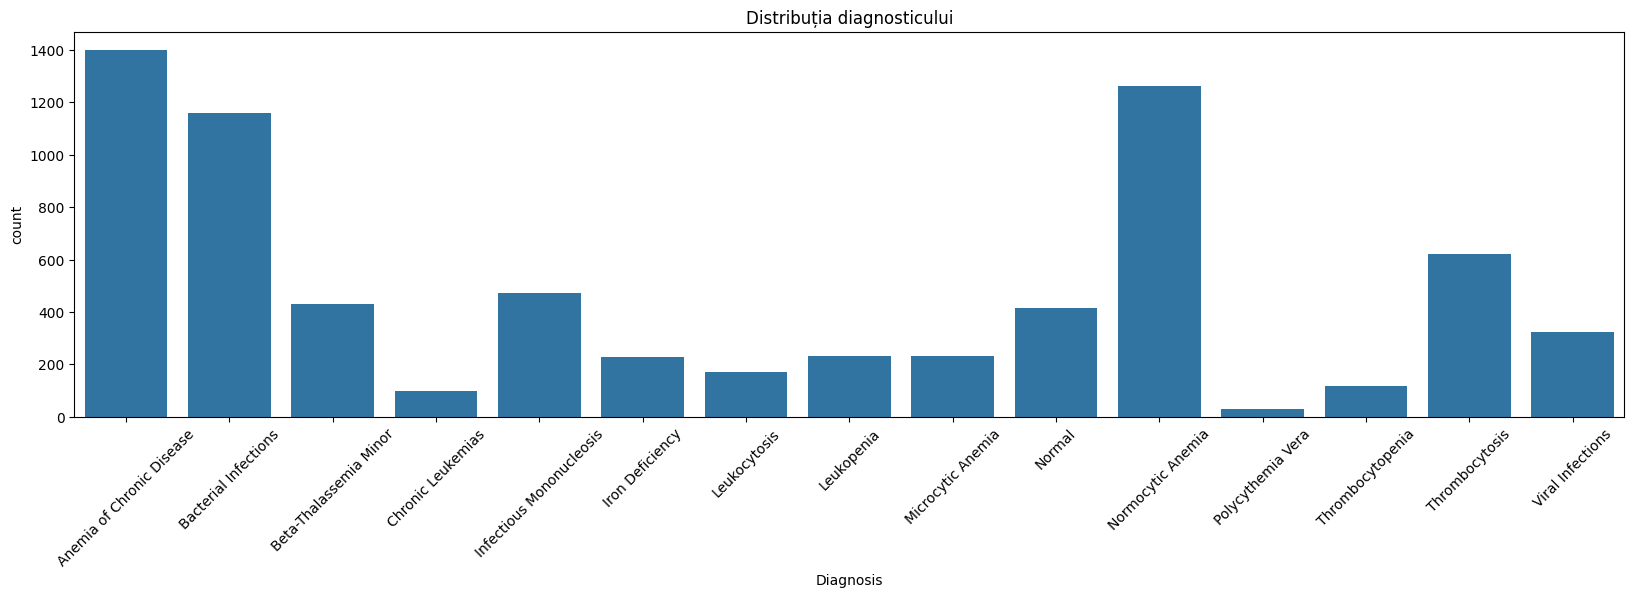

In [7]:
plt.figure(figsize=(20,5))
sns.countplot(x="Diagnosis", data=df)

plt.title("Distribuția diagnosticului")
plt.xticks(rotation=45)
plt.show()

### 2.4. Analiza parametrilor hematologici

Pentru analiza distribuției parametrilor hematologici, vom folosi histograme.

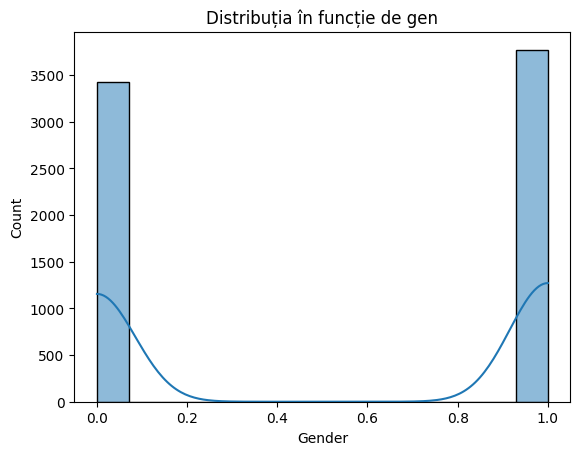

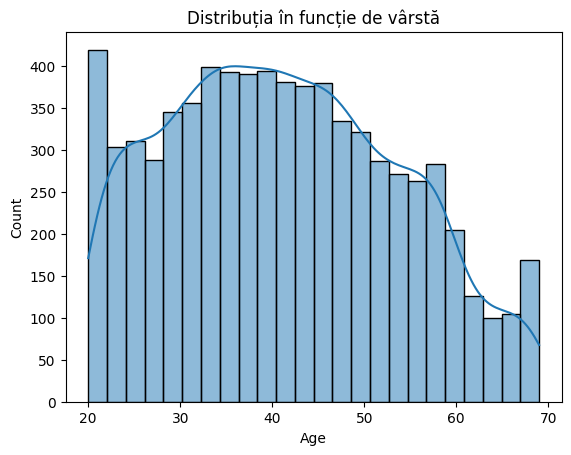

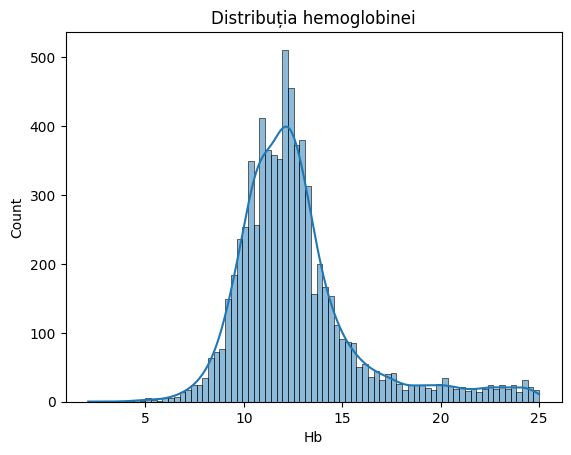

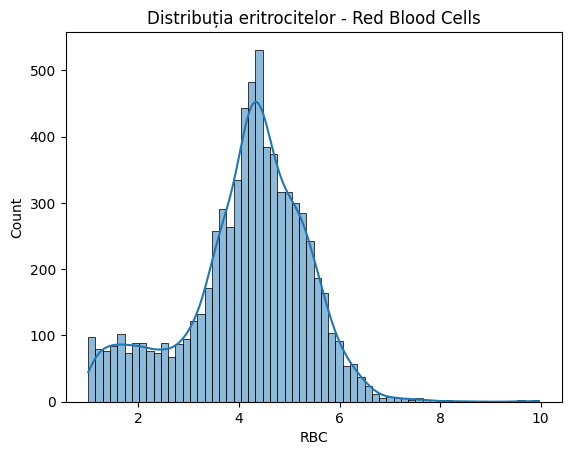

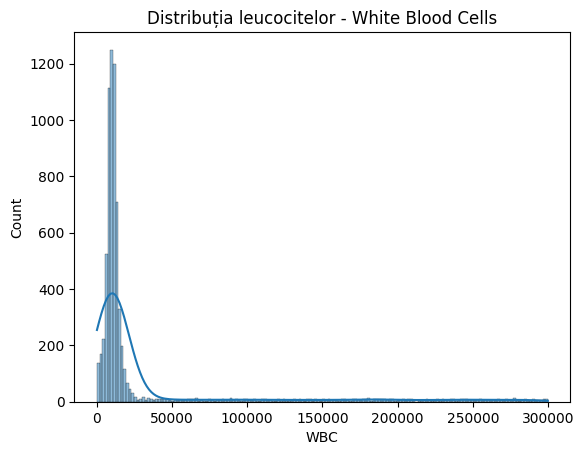

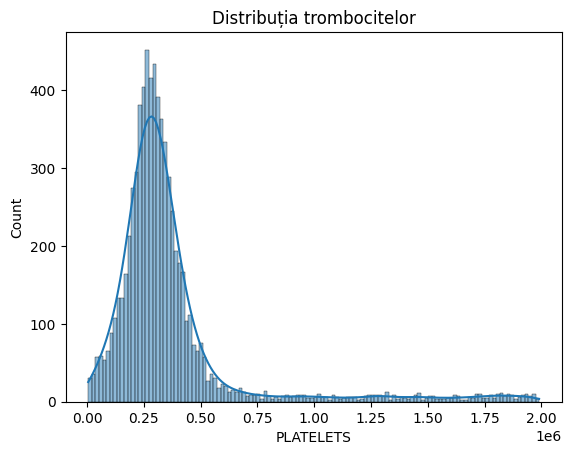

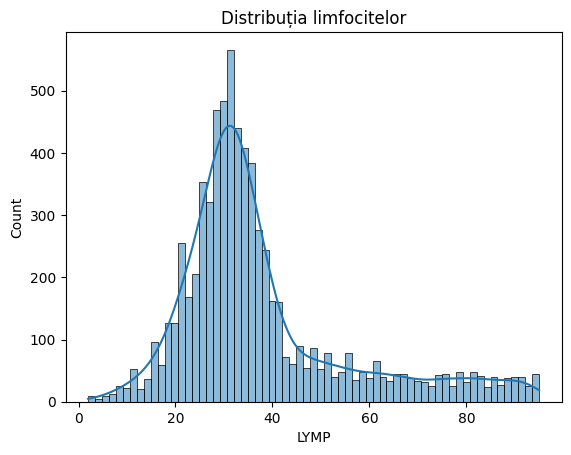

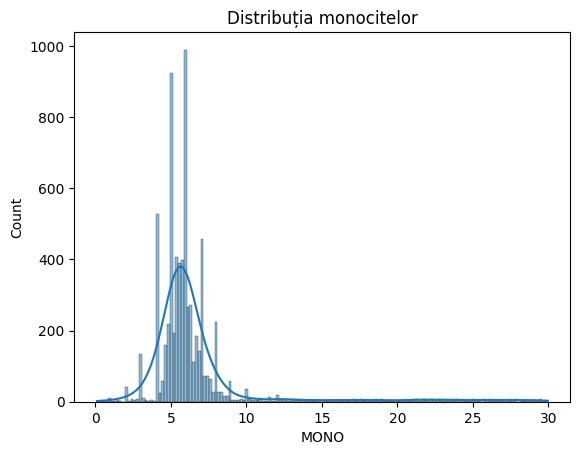

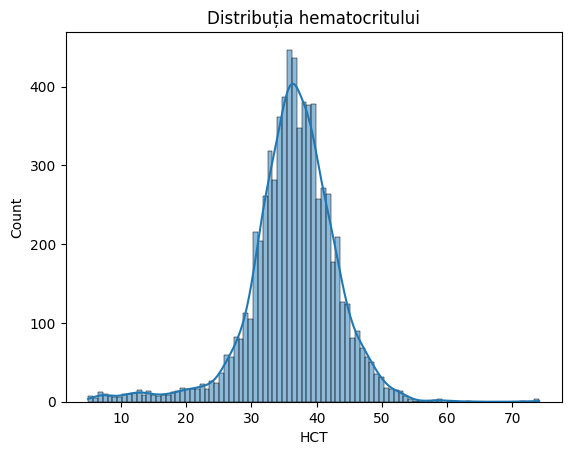

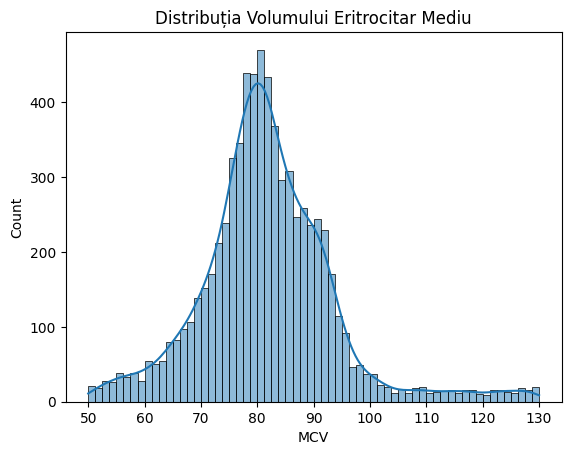

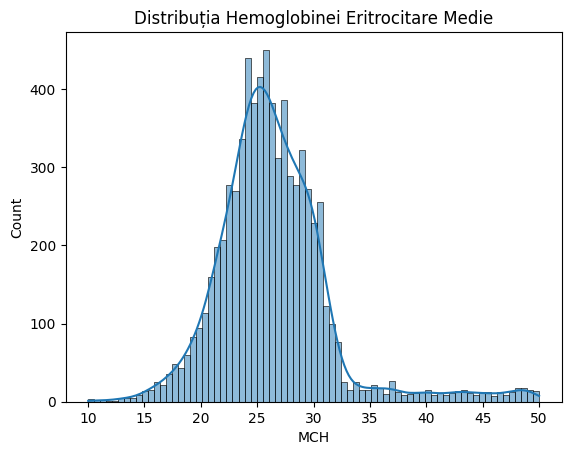

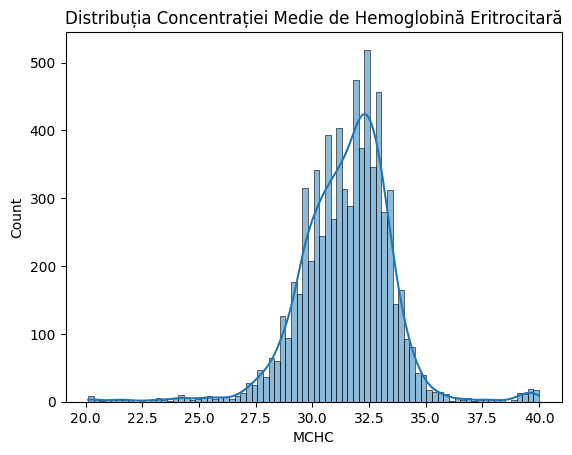

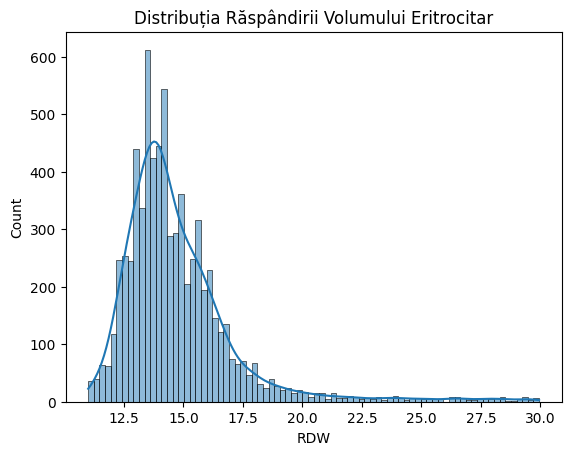

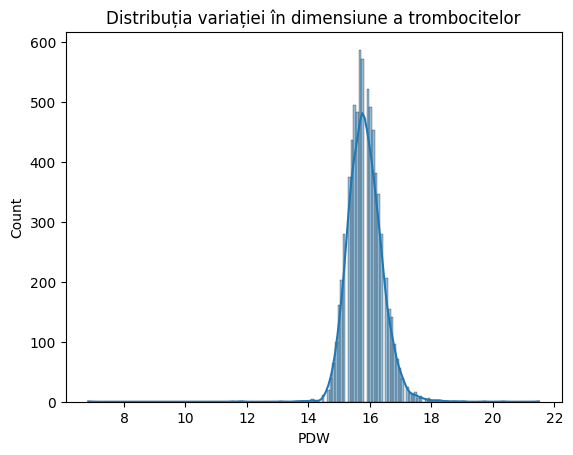

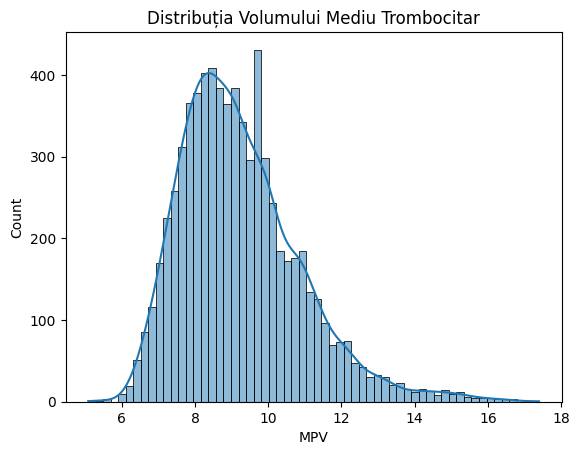

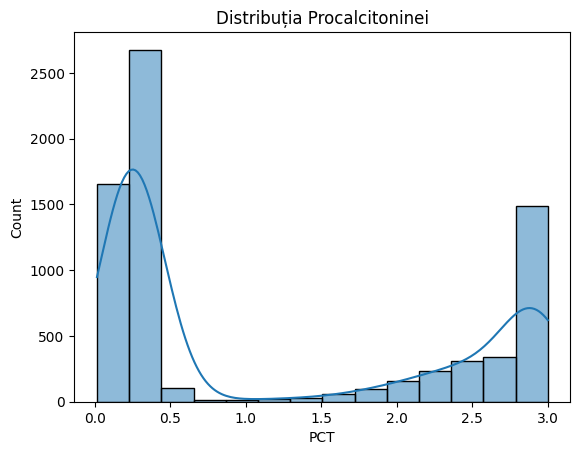

In [8]:
columns_to_plot = ["Gender", "Age", "Hb", "RBC", "WBC", "PLATELETS", "LYMP", "MONO",
                  "HCT", "MCV", "MCH", "MCHC", "RDW", "PDW", "MPV", "PCT"]
plt_titles = ["Distribuția în funcție de gen", 
              "Distribuția în funcție de vârstă", 
              "Distribuția hemoglobinei", 
              "Distribuția eritrocitelor - Red Blood Cells",
              "Distribuția leucocitelor - White Blood Cells",
              "Distribuția trombocitelor",
              "Distribuția limfocitelor",
              "Distribuția monocitelor",
              "Distribuția hematocritului",
              "Distribuția Volumului Eritrocitar Mediu",
              "Distribuția Hemoglobinei Eritrocitare Medie",
              "Distribuția Concentrației Medie de Hemoglobină Eritrocitară",
              "Distribuția Răspândirii Volumului Eritrocitar",
              "Distribuția variației în dimensiune a trombocitelor",
              "Distribuția Volumului Mediu Trombocitar",
              "Distribuția Procalcitoninei"
             ]
for i in range(16):
    plt.clf()
    sns.histplot(df[columns_to_plot[i]], kde=True)
    plt.title(plt_titles[i])
    plt.savefig(f"histogram_{columns_to_plot[i].lower()}.png", bbox_inches='tight', dpi=300)
    plt.show()


### 2.5. Detectarea valorilor extreme (outliers)

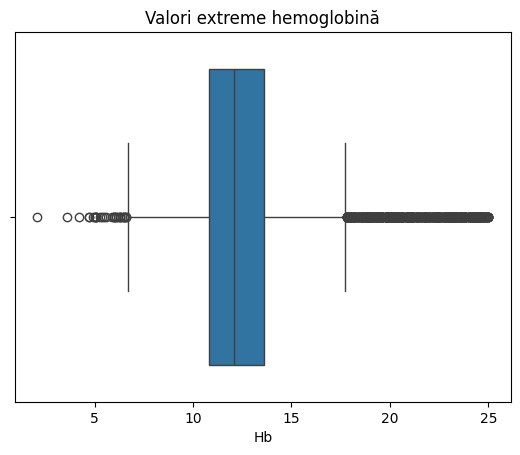

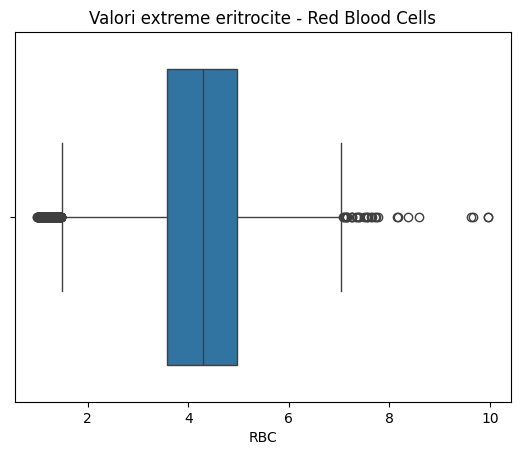

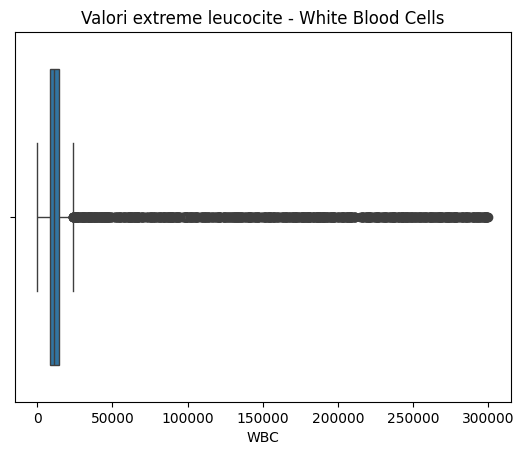

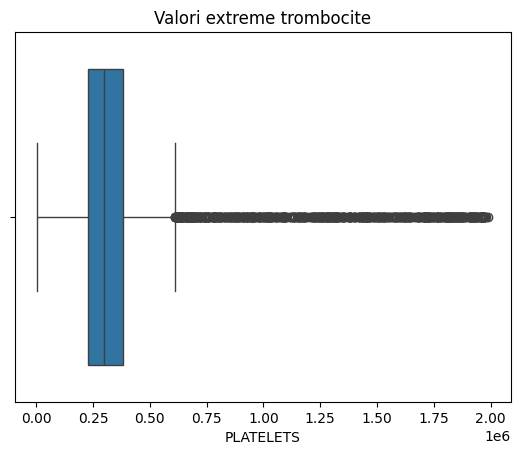

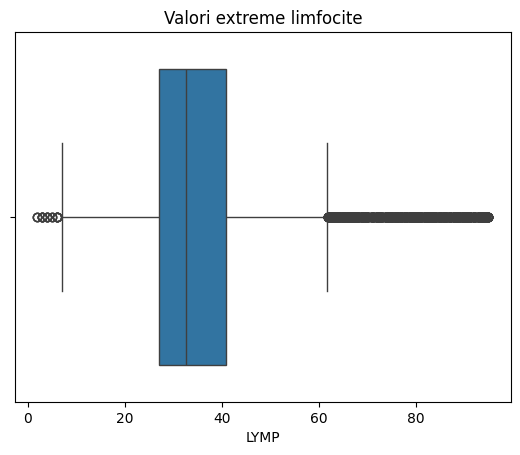

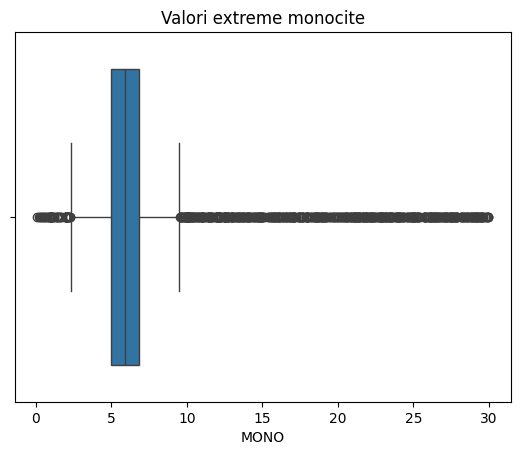

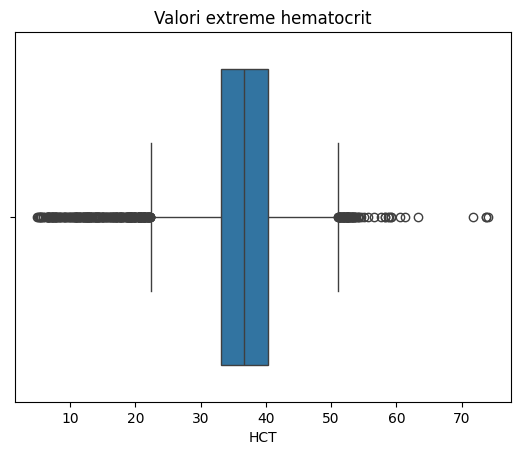

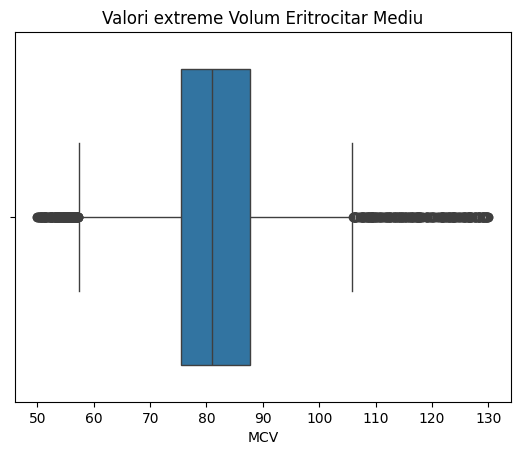

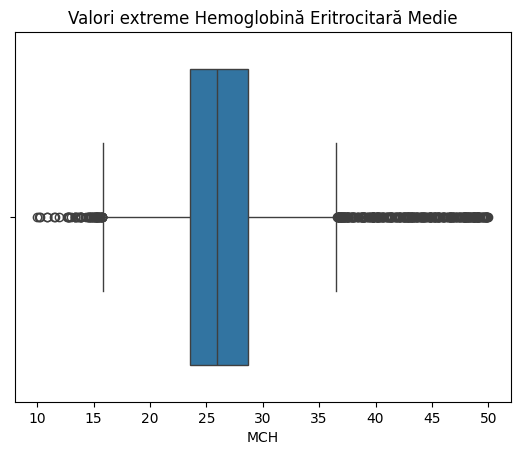

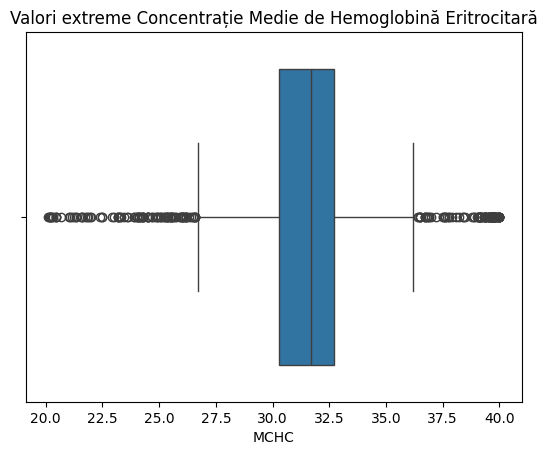

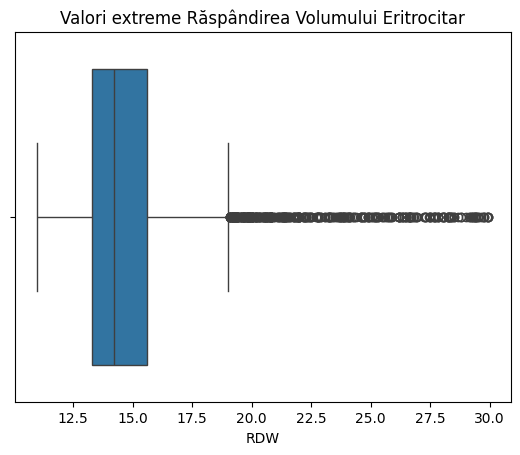

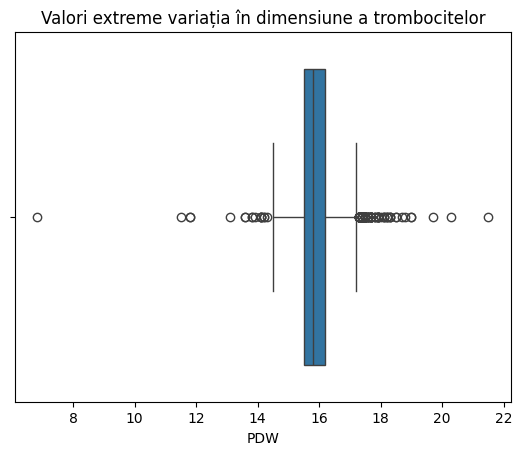

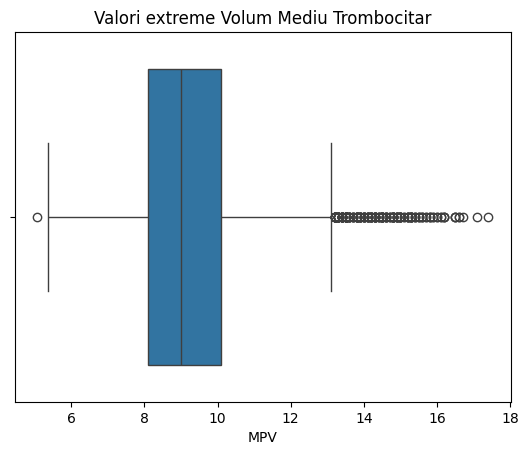

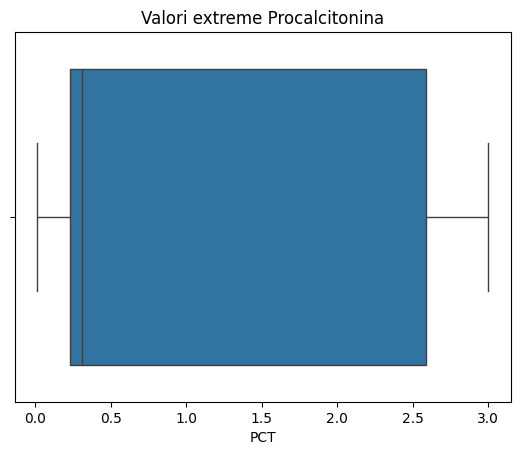

In [9]:

plt_outliers_titles = ["","","Valori extreme hemoglobină",
                      "Valori extreme eritrocite - Red Blood Cells",
                       "Valori extreme leucocite - White Blood Cells",
                       "Valori extreme trombocite",
                       "Valori extreme limfocite",
                       "Valori extreme monocite",
                       "Valori extreme hematocrit",
                       "Valori extreme Volum Eritrocitar Mediu",
                       "Valori extreme Hemoglobină Eritrocitară Medie",
                       "Valori extreme Concentrație Medie de Hemoglobină Eritrocitară",
                       "Valori extreme Răspândirea Volumului Eritrocitar",
                       "Valori extreme variația în dimensiune a trombocitelor",
                       "Valori extreme Volum Mediu Trombocitar",
                       "Valori extreme Procalcitonina"
                      ]
for i in range(2, 16):
    plt.clf()
    sns.boxplot(x=df[columns_to_plot[i]])
    plt.title(plt_outliers_titles[i])
    plt.savefig(f"outliers_{columns_to_plot[i].lower()}.png", bbox_inches='tight', dpi=300)
    plt.show()
    

### 2.6. Analiza corelațiilor

Pentru a verifica corelațiile dintre atribute, folosim matricea de corelație

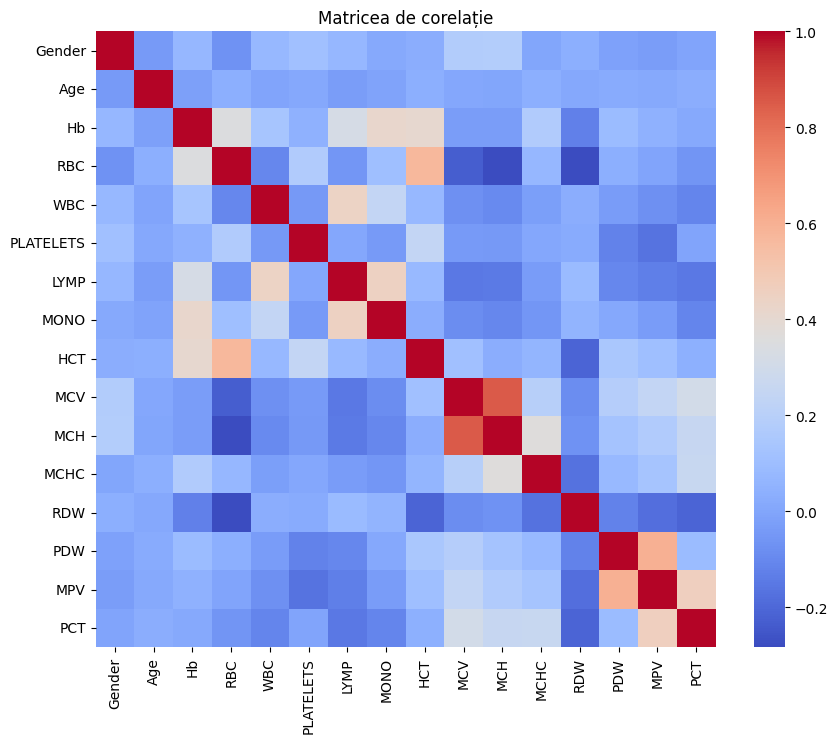

In [10]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=False)
plt.title("Matricea de corelație")
plt.show()

Observații:
- RBC(eritrocite) pot fi corelate cu HCT(hematocrit)
- MCV(Volum Eritrocitar Mediu) poate fi corelat cu MCH(Hemoglobină Eritrocitară Medie)
- PDW(variația în dimensiune a trombocitelor) poate fi corelată cu MVP(Volum Mediu Trombocitar)

## 3. Preprocesarea datelor

### 3.1. Verificarea și tratarea valorilor lipsă

Înainte de antrenarea modelului de clasificare este necesar să verificăm integritatea setului de date. În acest sens vom genera o listă de tupluri conținând denumirile coloanelor și numărul de valori nule aferente.

In [11]:
df.isnull().sum()

Gender       0
Age          0
Hb           0
RBC          0
WBC          0
PLATELETS    0
LYMP         0
MONO         0
HCT          0
MCV          0
MCH          0
MCHC         0
RDW          0
PDW          0
MPV          0
PCT          0
Diagnosis    0
dtype: int64

Rezultatul obținut ne indică faptul că datasetul nu conține nicio valoare lipsă.

*Notă: În situația în care am fi identificat valori lipsă am fi putut să le înlocuim cu o medie a valorilor din coloană (df = df.fillna(df.mean(numeric_only=True)))*

### 3.2. Separarea atributelor independente și a atributului țintă

Pasul următor este să separăm:
- atributele explicative, în cazul de față analizele hematologice -> **features**
- atributul țintă, respectiv diagnosticul -> **target**

In [12]:
X = df.drop("Diagnosis", axis=1)
y = df["Diagnosis"]

Astfel, **X** va conține toate atributele de intrare, iar **y** va conține diagnosticul.

### 3.3. Codificarea atributului de diagnostic

În datasetul analizat, coloana "Diagnosis" conține valori de tip text (de exemplu: Anemia of Chronic Disease). Pentru eficietizarea modelului din scikit-learn, vom transforma valorile din această coloană în valori numerice. În acest sens, vom folosi LabelEncoder.

In [13]:
from sklearn.preprocessing import LabelEncoder
# import pandas as pd

# Afișăm valorile inițiale ale diagnosticului în format text
print("Diagnosticele în format text: ")
print(y[:10])

# Inițializăm encoderul
le = LabelEncoder()

# Transformăm valorile din format text în format numeric
y_encoded = le.fit_transform(y)

#Afisăm corespondența dintre clase și valorile numerice
print("\nCorespondența dintre diagnostice și valorile numerice: ")
label_mapping = pd.DataFrame({"Diagnostic": le.classes_, "Cod Numeric":range(len(le.classes_))})

print(label_mapping)

Diagnosticele în format text: 
0    Anemia of Chronic Disease
1    Anemia of Chronic Disease
2    Anemia of Chronic Disease
3    Anemia of Chronic Disease
4    Anemia of Chronic Disease
5    Anemia of Chronic Disease
6    Anemia of Chronic Disease
7    Anemia of Chronic Disease
8    Anemia of Chronic Disease
9    Anemia of Chronic Disease
Name: Diagnosis, dtype: str

Corespondența dintre diagnostice și valorile numerice: 
                   Diagnostic  Cod Numeric
0   Anemia of Chronic Disease            0
1        Bacterial Infections            1
2      Beta-Thalassemia Minor            2
3           Chronic Leukemias            3
4    Infectious Mononucleosis            4
5             Iron Deficiency            5
6                Leukocytosis            6
7                  Leukopenia            7
8           Microcytic Anemia            8
9                      Normal            9
10          Normocytic Anemia           10
11          Polycythemia Vera           11
12           Th

## 4. Împărțirea datasetului în set de antrenare și set de test

În această etapă împărțim datele în două subseturi:
- **training set** pentru antrenarea modelului (80% din date)
- **test set** pentru evaluarea performanței (20% din date)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

**Note**: 

- Numărul 42 utilizat pentru random_state este ales în mod convențional pentru a asigura reproductibilitatea rezultatelor.
- Folosim *stratify=y_encoded* astfel încât toate clasele să apară atât în train cât și în test.

În timpul evaluării ROC am identificat clase pentru care nu existau exemple în setul de testare, ceea ce a condus la imposibilitatea calculării unor metrici. Pentru a evita această problemă, utilizăm împărțirea stratificată a datelor, pentru o distribuție echilibrată a claselor între seturile de antrenare și de testare.


În urma preprocesării vom avea:
 - **X_train** care conține atributele pentru antrenare
 - **X_test** care conține atributele pentru testare
 - **y_train** care conține diagnostice pentru antrenare
 - **y_test** care conține diagnostice pentru testare

## 5. Implementarea modelului Decision Tree

### 5.1. Importul bibliotecilor necesare

Algoritmul Decision Tree construiește un model de clasificare care are forma unei structuri arborescente, unde fiecare nod reprezintă o condiție aplicată unui atribut, iar fiecare frunză reprezintă o clasă de diagnostic.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

### 5.2. Crearea modelului

Continuăm prin instanțierea modelului:

In [16]:
model_dt = DecisionTreeClassifier(random_state=42)

### 5.3. Antrenarea modelului

Următorul pas este să antrenăm modelul pe setul de antrenare(X_train și y_train).

In [17]:
model_dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

### 5.4. Analiza modelului în vederea determinării necesității de optimizare

În urma antrenării modelului, se construiește o structură aborescentă formată din noduri și frunze. 

In [18]:
print("Numărul total al nodurilor din arbore: ", model_dt.tree_.node_count)
print("Adâncimea maximă a arborelui: ", model_dt.tree_.max_depth)

Numărul total al nodurilor din arbore:  335
Adâncimea maximă a arborelui:  13


În procesul de antrenare, algoritmul selectează atributele relevante pentru maximizarea separării între clase.

WBC          22
PLATELETS    18
HCT          17
LYMP         16
Hb           14
MCV          12
Gender       12
MCH          11
MONO         11
RBC           8
MCHC          8
PCT           5
Age           5
RDW           3
PDW           3
MPV           2
Name: count, dtype: int64


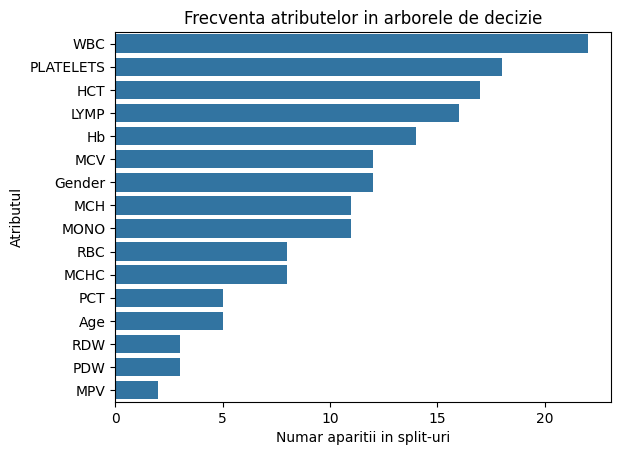

In [19]:
import matplotlib.pyplot as plt
import importlib
importlib.reload(plt)

# Extragem indexii atributelor folosite
features_used = model_dt.tree_.feature

# Filtram nodurile terminale (-2)
features_used = features_used[features_used != -2]

# Numaram aparitiile fiecarui atribut
feature_counts = pd.Series(features_used).value_counts()

# Transformam indexii in nume de coloane
feature_counts.index = [X.columns[i] for i in feature_counts.index]

# Sortam descrescator
feature_counts = feature_counts.sort_values(ascending=False)
print(feature_counts)

sns.barplot(x=feature_counts.values, y=feature_counts.index)
plt.title("Frecventa atributelor in arborele de decizie")
plt.xlabel("Numar aparitii in split-uri")
plt.ylabel("Atributul")
plt.show()

Mai jos, verificăm importanța atributelor:

In [20]:
import pandas as pd
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_dt.feature_importances_
})
print(feature_importance.sort_values(by="Importance", ascending=False))

      Feature  Importance
2          Hb    0.184338
4         WBC    0.160969
6        LYMP    0.115917
12        RDW    0.102759
5   PLATELETS    0.097160
3         RBC    0.095838
11       MCHC    0.057536
7        MONO    0.056265
0      Gender    0.040376
10        MCH    0.039037
8         HCT    0.021763
9         MCV    0.021099
1         Age    0.004054
15        PCT    0.001647
13        PDW    0.001019
14        MPV    0.000221


Pragurile de separare (split thresholds), conținute în fiecare nod, pot fi extrase după cum urmează:

In [21]:
attribute_name = X.columns
tree = model_dt.tree_
print(f"{'Atribut':<20} | {'Prag de taiere':<15}")
print("-" * 40)

# Parcugem primele 10 noduri
for i in range(10):
    # Verificam daca nodul nu este o frunza
    if tree.feature[i] != -2:
        col_name = attribute_name[tree.feature[i]]
        threshold = tree.threshold[i]
        print(f"{col_name:<20} | {threshold:<15.4f}")
    else:
        print(f"{'Nod frunza':<20} | {'---':<15}")

Atribut              | Prag de taiere 
----------------------------------------
RDW                  | 15.0500        
RBC                  | 4.4950         
Hb                   | 12.9500        
MCHC                 | 30.5650        
MCV                  | 76.1250        
RBC                  | 3.8150         
MCH                  | 27.1000        
HCT                  | 40.0000        
Nod frunza           | ---            
Nod frunza           | ---            


În cadrul procesului de antrenare, datasetul se împarte în subseturi din ce în ce mai mici.

In [22]:
samples = model_dt.tree_.n_node_samples
print("Numărul de observații din primele noduri: ")
print(samples[:10])

Numărul de observații din primele noduri: 
[5756 3844 1956 1614  254  200  170  162  159    3]


In [23]:
for i in range(20):
    feature_idx = model_dt.tree_.feature[i]
    if feature_idx != -2: # Daca nu este nod frunza
        name = X.columns[feature_idx]
        threshold = model_dt.tree_.threshold[i]
        count = model_dt.tree_.n_node_samples[i]
        print(f"Nodul {i}: Daca {name} <= {threshold:.2f}, separa {count} pacienti")

Nodul 0: Daca RDW <= 15.05, separa 5756 pacienti
Nodul 1: Daca RBC <= 4.49, separa 3844 pacienti
Nodul 2: Daca Hb <= 12.95, separa 1956 pacienti
Nodul 3: Daca MCHC <= 30.57, separa 1614 pacienti
Nodul 4: Daca MCV <= 76.12, separa 254 pacienti
Nodul 5: Daca RBC <= 3.81, separa 200 pacienti
Nodul 6: Daca MCH <= 27.10, separa 170 pacienti
Nodul 7: Daca HCT <= 40.00, separa 162 pacienti
Nodul 11: Daca Gender <= 0.50, separa 30 pacienti
Nodul 14: Daca HCT <= 39.90, separa 54 pacienti
Nodul 15: Daca LYMP <= 18.00, separa 45 pacienti
Nodul 16: Daca MCH <= 26.20, separa 3 pacienti


De asemenea, putem genera un grafic ce conține următoarele informații pentru fiecare nod al arborelui, pentru primele 2 niveluri:
- atributul folosit pentru split( ex: RDW, RBC, Hb, etc.)
- pragul de separare
- gini impurity
- numărul de eșantioane (samples)
- clasa dominantă (class)

Din analiza graficului, putem calcula Information Gain.

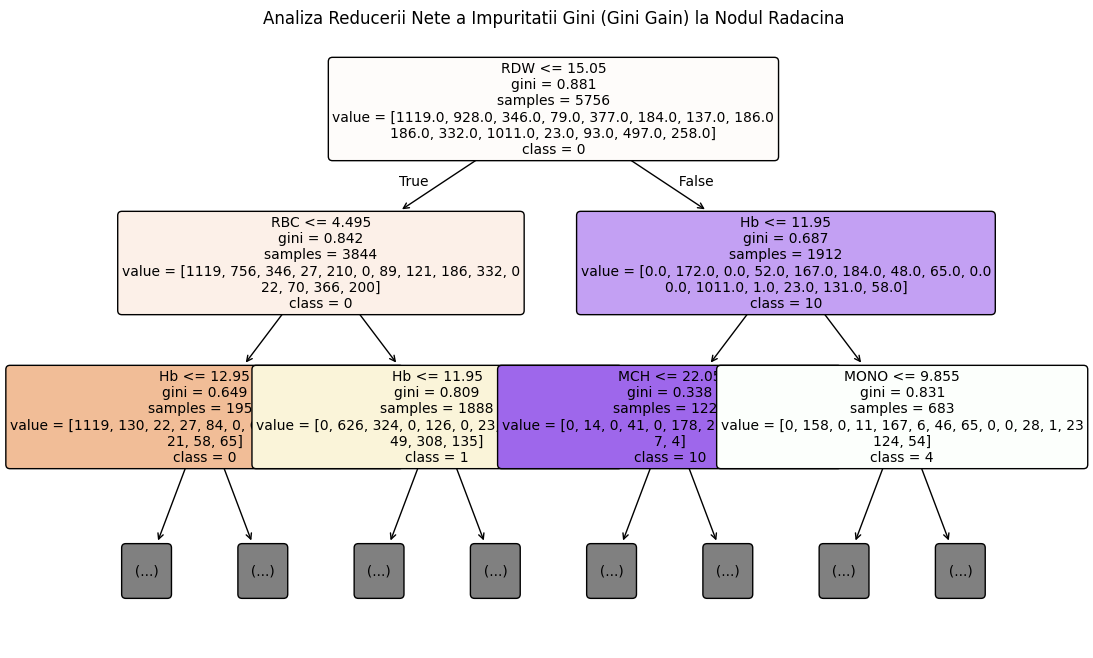

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

class_names_list = [str(c) for c in model_dt.classes_]
plt.figure(figsize=(12,8))
# Afisam doar primele 2 niveluri
plot_tree(
    model_dt,
    feature_names=list(X.columns),
    class_names = class_names_list,
    filled=True,
    max_depth=2,
    fontsize=10,
    rounded=True
)
plt.title("Analiza Reducerii Nete a Impuritatii Gini (Gini Gain) la Nodul Radacina")
plt.show()

**Vizualizarea regulilor:**

Arborele de decizie generează reguli de clasificare de tip IF-THEN. 

Extragerea regulilor se poate efectua după cum urmează:

In [25]:
from sklearn.tree import export_text
rules = export_text(model_dt, feature_names=list(X.columns))
print(rules)

|--- RDW <= 15.05
|   |--- RBC <= 4.49
|   |   |--- Hb <= 12.95
|   |   |   |--- MCHC <= 30.57
|   |   |   |   |--- MCV <= 76.12
|   |   |   |   |   |--- RBC <= 3.81
|   |   |   |   |   |   |--- MCH <= 27.10
|   |   |   |   |   |   |   |--- HCT <= 40.00
|   |   |   |   |   |   |   |   |--- class: 8
|   |   |   |   |   |   |   |--- HCT >  40.00
|   |   |   |   |   |   |   |   |--- class: 3
|   |   |   |   |   |   |--- MCH >  27.10
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- RBC >  3.81
|   |   |   |   |   |   |--- Gender <= 0.50
|   |   |   |   |   |   |   |--- class: 8
|   |   |   |   |   |   |--- Gender >  0.50
|   |   |   |   |   |   |   |--- class: 2
|   |   |   |   |--- MCV >  76.12
|   |   |   |   |   |--- HCT <= 39.90
|   |   |   |   |   |   |--- LYMP <= 18.00
|   |   |   |   |   |   |   |--- MCH <= 26.20
|   |   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |   |--- MCH >  26.20
|   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   

Regulile generate mai sus sunt de tipul:

**IF** RDW <= 15.05 AND RBC <= 4.48 AND Hb <= 12.95 AND MCV <= 75.97 AND MCHC <= 30.95 AND RBC <= 3.82 AND MCH <= 27.10 AND HCT <= 40.04 AND PCT <= 0.14 AND MPV <= 9.55
**THEN** Leukocytosis

Extragerea automată a regulilor din arbore:

In [26]:
def extract_rules(model_dt, feature_names, class_names):
    rules=[]
    tree = model_dt.tree_

    def recurse(node, path):
        # daca NU este frunza:
        if tree.feature[node] != -2:
            name = feature_names[tree.feature[node]]
            threshold = tree.threshold[node]
            
            #Stanga
            recurse(tree.children_left[node], path + [f"{name} <= {threshold:.2f}"])
            
            #Dreapta
            recurse(tree.children_right[node], path + [f"{name} > {threshold:.2f}"])
        else:
            # daca este frunza, determinam clasa
            values = tree.value[node][0]
            class_index = values.argmax()
            class_name = class_names[class_index]
            
            rules.append((path, class_name))
    recurse(0,[])
    return rules
rules = extract_rules(model_dt, X.columns, le.classes_)

for i, (conditions, class_name) in enumerate(rules, start=1):
    rule_text = " AND ".join(conditions)
    print(f"Regula {i}: IF  {rule_text}   THEN   Clasa: {class_name}")

Regula 1: IF  RDW <= 15.05 AND RBC <= 4.49 AND Hb <= 12.95 AND MCHC <= 30.57 AND MCV <= 76.12 AND RBC <= 3.81 AND MCH <= 27.10 AND HCT <= 40.00   THEN   Clasa: Microcytic Anemia
Regula 2: IF  RDW <= 15.05 AND RBC <= 4.49 AND Hb <= 12.95 AND MCHC <= 30.57 AND MCV <= 76.12 AND RBC <= 3.81 AND MCH <= 27.10 AND HCT > 40.00   THEN   Clasa: Chronic Leukemias
Regula 3: IF  RDW <= 15.05 AND RBC <= 4.49 AND Hb <= 12.95 AND MCHC <= 30.57 AND MCV <= 76.12 AND RBC <= 3.81 AND MCH > 27.10   THEN   Clasa: Anemia of Chronic Disease
Regula 4: IF  RDW <= 15.05 AND RBC <= 4.49 AND Hb <= 12.95 AND MCHC <= 30.57 AND MCV <= 76.12 AND RBC > 3.81 AND Gender <= 0.50   THEN   Clasa: Microcytic Anemia
Regula 5: IF  RDW <= 15.05 AND RBC <= 4.49 AND Hb <= 12.95 AND MCHC <= 30.57 AND MCV <= 76.12 AND RBC > 3.81 AND Gender > 0.50   THEN   Clasa: Beta-Thalassemia Minor
Regula 6: IF  RDW <= 15.05 AND RBC <= 4.49 AND Hb <= 12.95 AND MCHC <= 30.57 AND MCV > 76.12 AND HCT <= 39.90 AND LYMP <= 18.00 AND MCH <= 26.20   TH

Observăm existența unor reguli redundante, care nu schimbă rezultatul, de exemplu verificarea din cadrul regulilor 156 și 157 a valorii MPV, care nu schimbă clasa finală de Thrombocytosis:
- Regula 156: IF  RDW > 15.05 AND Hb > 11.95 AND MONO <= 9.86 AND WBC > 11020.00 AND LYMP <= 43.95 AND HCT > 23.77 AND MCH > 28.55 AND Gender > 0.50 AND MCH > 32.55 AND MPV <= 7.85   THEN   Clasa: Thrombocytosis
- Regula 157: IF  RDW > 15.05 AND Hb > 11.95 AND MONO <= 9.86 AND WBC > 11020.00 AND LYMP <= 43.95 AND HCT > 23.77 AND MCH > 28.55 AND Gender > 0.50 AND MCH > 32.55 AND MPV > 7.85   THEN   Clasa: Thrombocytopenia


Acest comportament al arborelui de decizie este cel mai probabil cauzat de lipsa tăierilor (pruning) sau o posibilă supra-învățare a modelului(overfitting).


### 5.5. Strategii de regularizare

#### 5.5.1. Limitarea manuală a adâncimii și a split-urilor

Vom utiliza tăierea anticipată - pre-pruning, prin limitarea adâncimii, pentru a reduce overfitting-ul:

In [27]:
from sklearn.tree import DecisionTreeClassifier
model_dt_pruned = DecisionTreeClassifier(
    max_depth=4,   # limiteaza complexitatea
    min_samples_leaf=10,   # elimina split-uri pe putine exemple
    random_state=42
)
model_dt_pruned.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

#### 5.5.2. Optimizarea automată prin Cost Complexity Pruning

Folosim cost-complexity pruning(ccp) pentru a permite algoritmului să determine automat care sunt ramurile cele mai slabe din punct de vedere statistic, folosind parametrul ccp_alpha. Astfel putem evita scăderea drastică a acurateței, evitând underfitting-ul.

Un ccp_alpha mic (0.01) elimină doar ramurile inutile.

Pruning automat

In [28]:
path = model_dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
models=[]
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    models.append(clf)

Vizualizarea performanței:

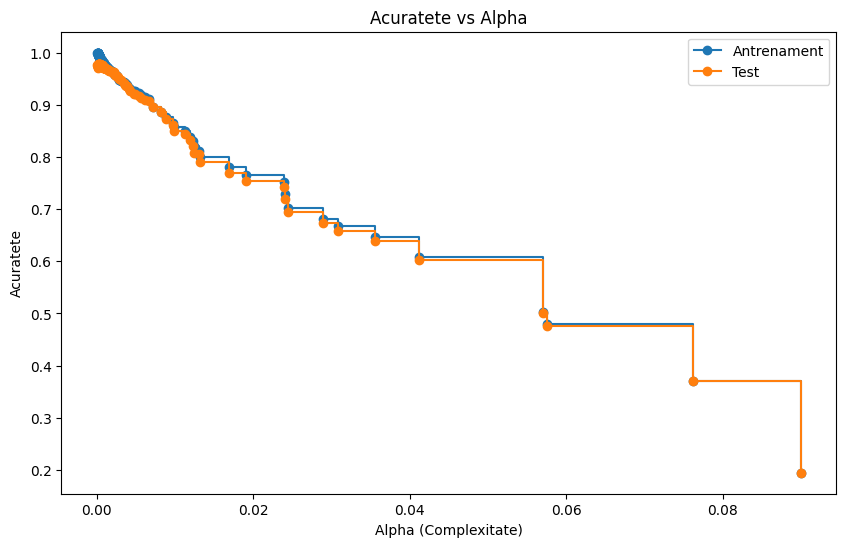

In [29]:
# import matplotlib.pyplot as plt

train_scores = [clf.score(X_train, y_train) for clf in models]
test_scores = [clf.score(X_test, y_test) for clf in models]

plt.figure(figsize=(10,6))
plt.plot(ccp_alphas, train_scores, marker='o', label="Antrenament", drawstyle="steps-post")
plt.plot(ccp_alphas, test_scores, marker='o', label="Test", drawstyle="steps-post")
plt.xlabel("Alpha (Complexitate)")
plt.ylabel("Acuratete")
plt.title("Acuratete vs Alpha")
plt.legend()
plt.show()

Selectăm cel mai bun model automat:

In [30]:
# Gasim indexul modelului cu cea mai mare acuratete pe test
best_model_idx = test_scores.index(max(test_scores))
best_model_dt = models[best_model_idx]
best_alpha = ccp_alphas[best_model_idx]

print(f"Cea mai buna acuratete pe Test: {max(test_scores):.2f}")
print(f"Valoarea optima pentru Alpha: {best_alpha:.4f}")


Cea mai buna acuratete pe Test: 0.98
Valoarea optima pentru Alpha: 0.0003


## 6. Realizarea predicțiilor

În urma antrenării modelului, acesta poate prezice diagnosticul pentru date noi. Vom testa predicțiile pentru setul de test. Predicțiile obținute reprezintă diagnosticul estimat de model pentru datele din setul de test.

In [31]:
y_pred_dt_best = best_model_dt.predict(X_test)

## 7. Vizualizarea arborelui de decizie

Mai jos, vom reprezenta grafic Arborele de Decizie, unde putem observa:
- nodurile arborelui
- condițiile de separare
- clasele rezultate

Întâi, vom reprezenta Arborele de Decizie inițial, înainte de rezolvarea overfittingului:

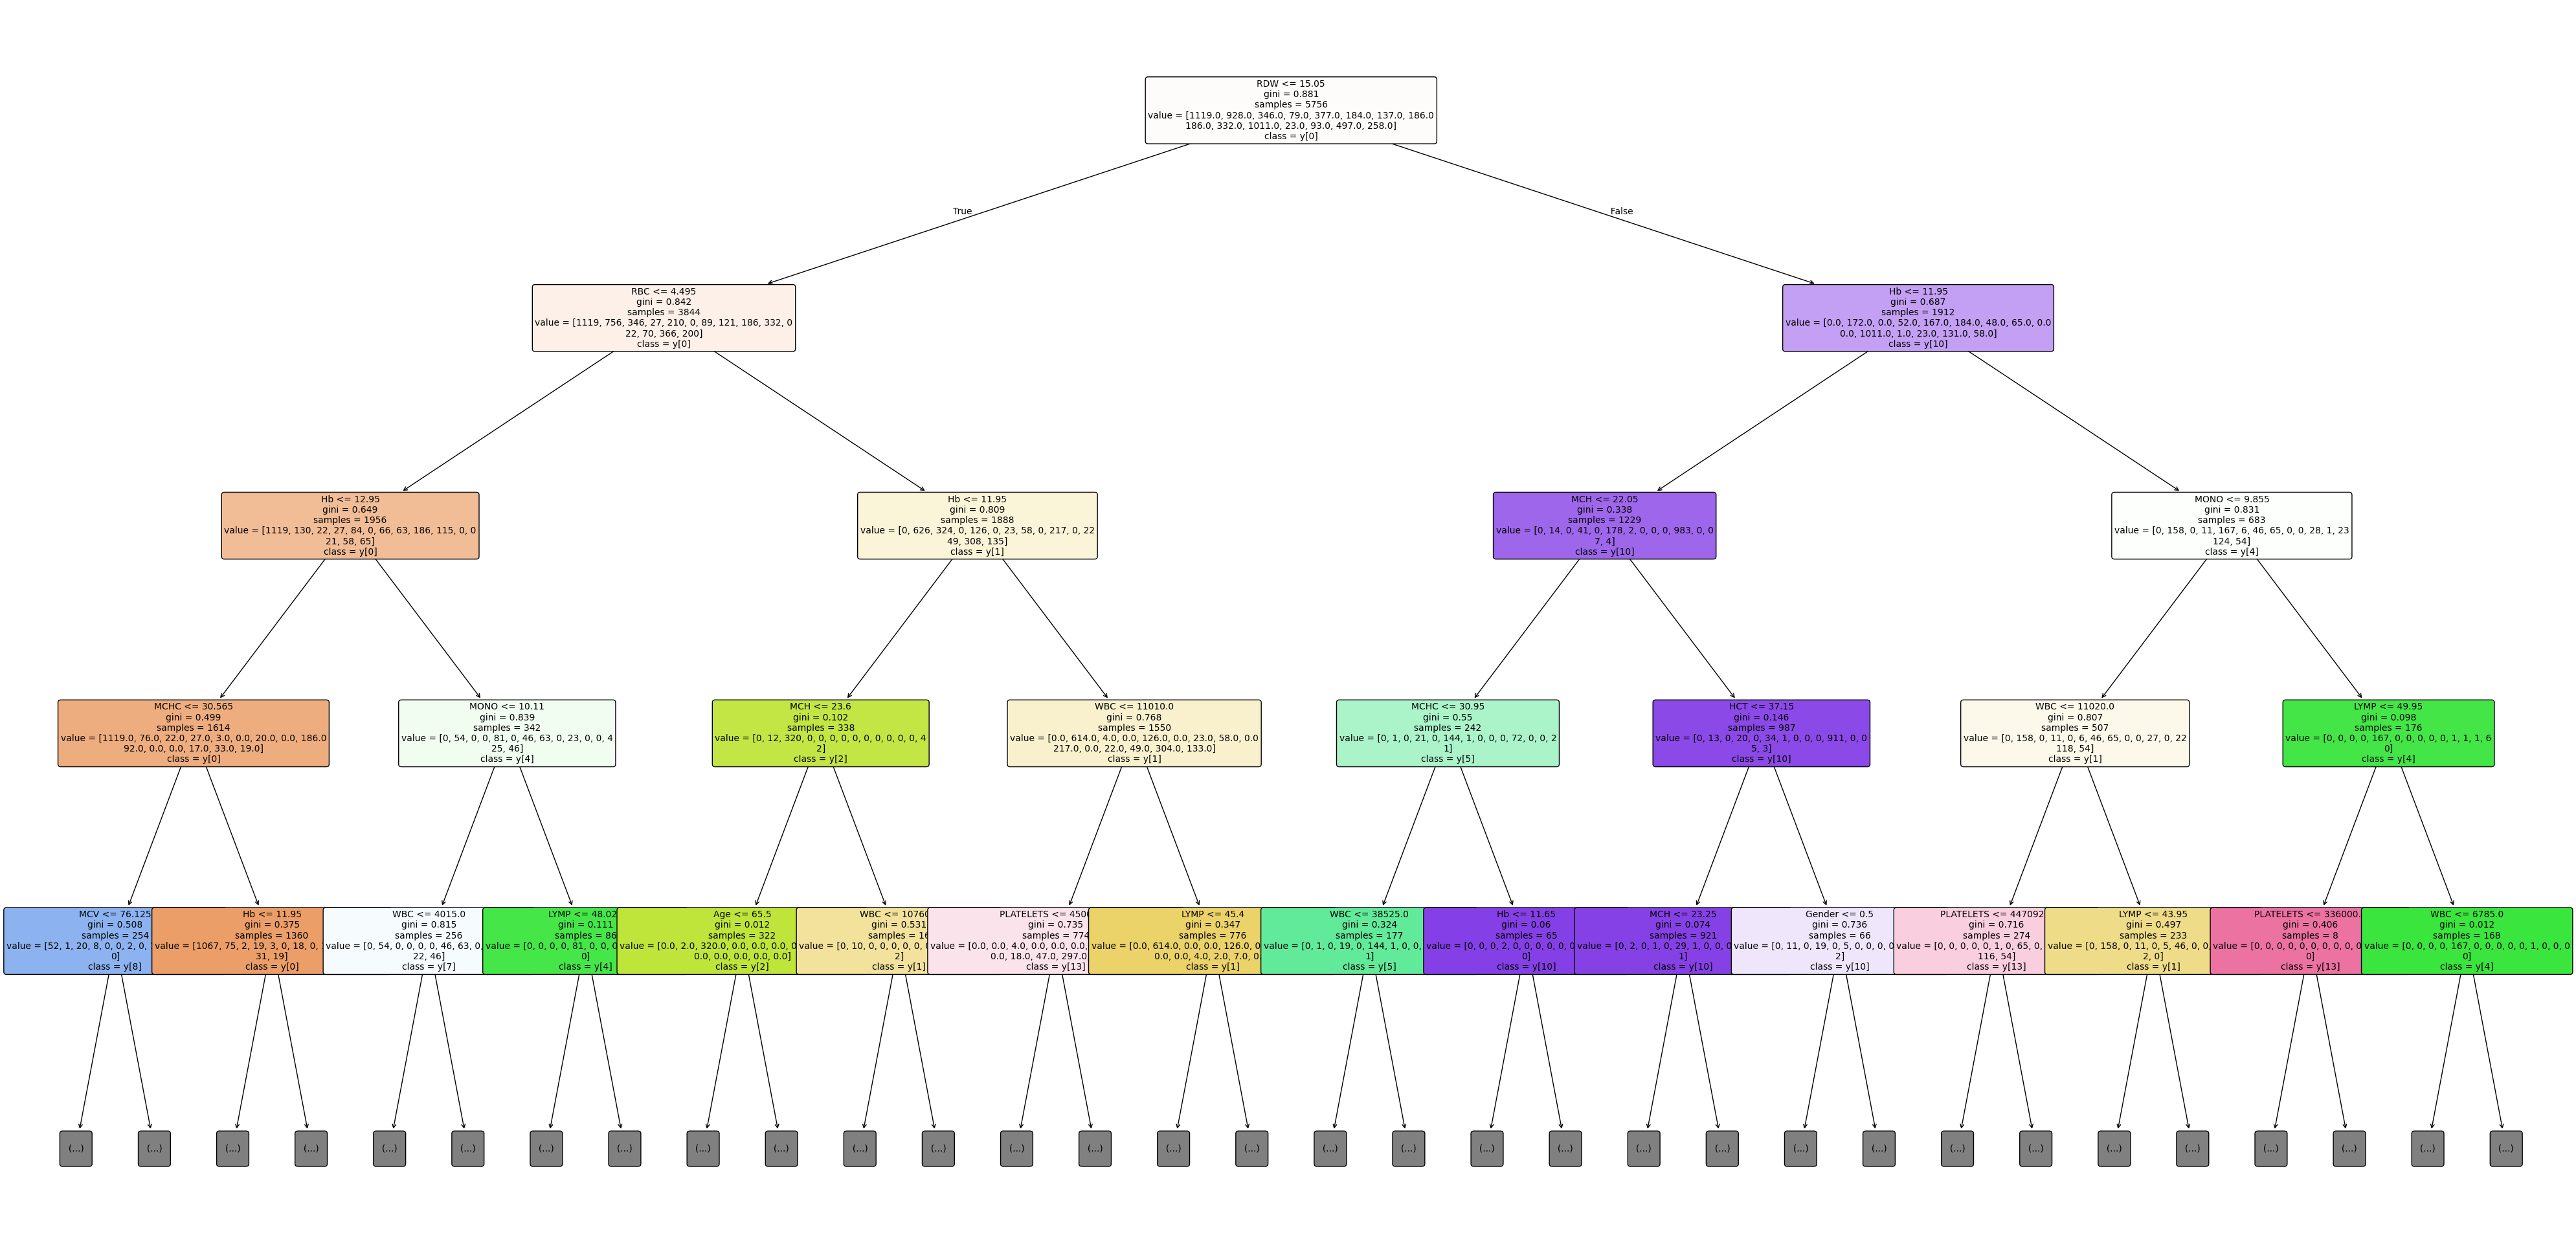

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(50,25))

plot_tree(model_dt, 
          max_depth=4,
          filled=True, 
          feature_names=X.columns, 
          class_names=True,
          rounded=True,
          fontsize=10
         )

plt.savefig(f"DT_initial.pdf", bbox_inches='tight')

plt.show()

Ulterior, reprezentăm grafic Arborele de decizie rezultat în urma pruningului:

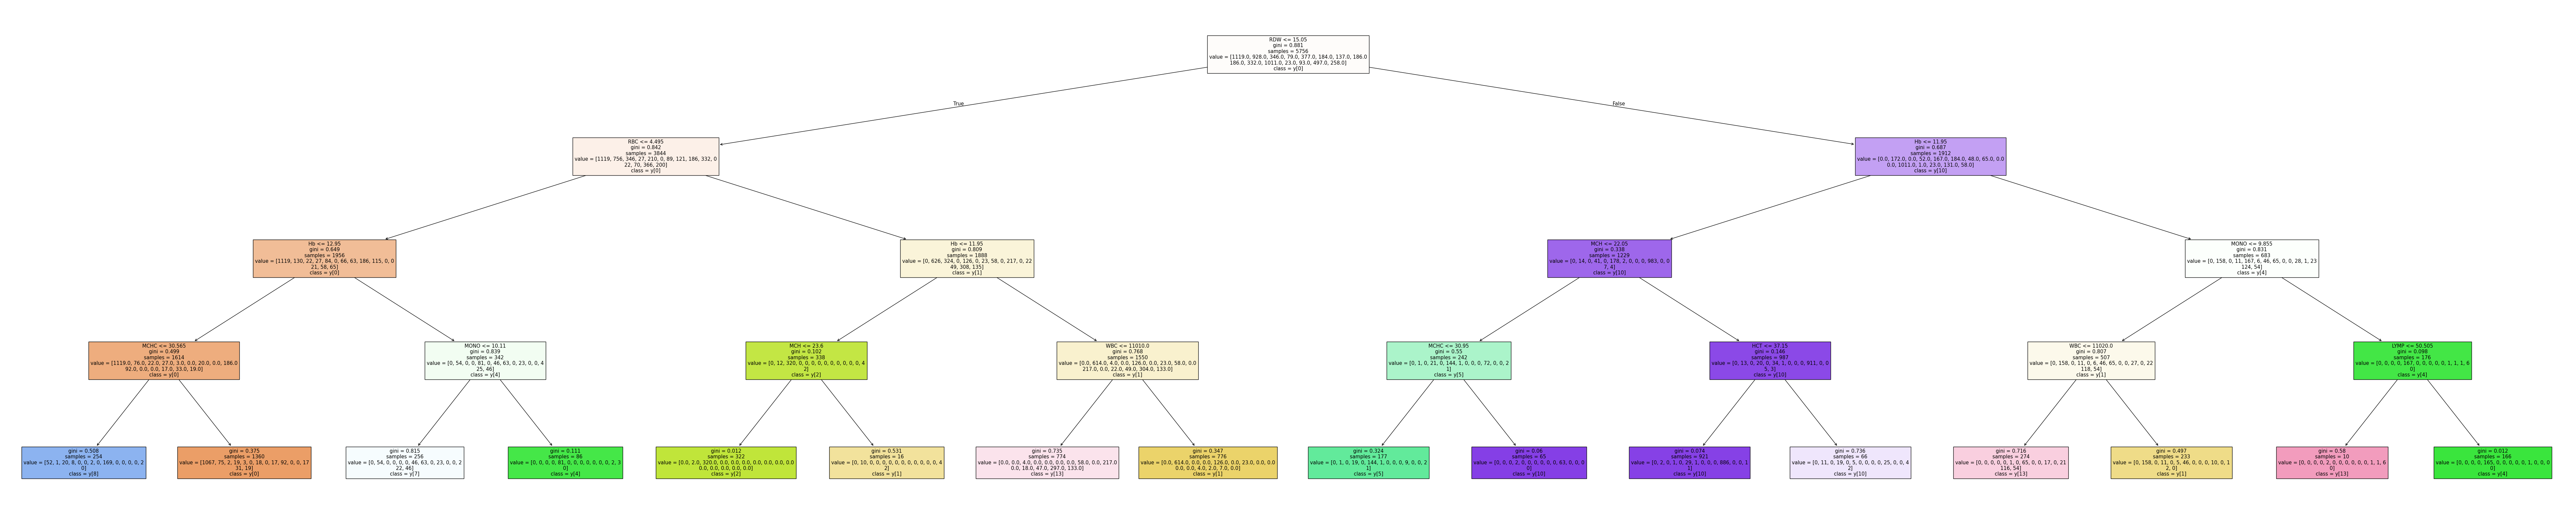

In [33]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(100,20))

plot_tree(model_dt_pruned,
          filled=True, 
          feature_names=X.columns, 
          class_names=True)

plt.savefig(f"DT_pruned.pdf", bbox_inches='tight')

plt.show()

La urmă, reprezentăm grafic Arborele de decizie cel mai performant, ca urmare a evitării overfittingului sau a underfittingului:

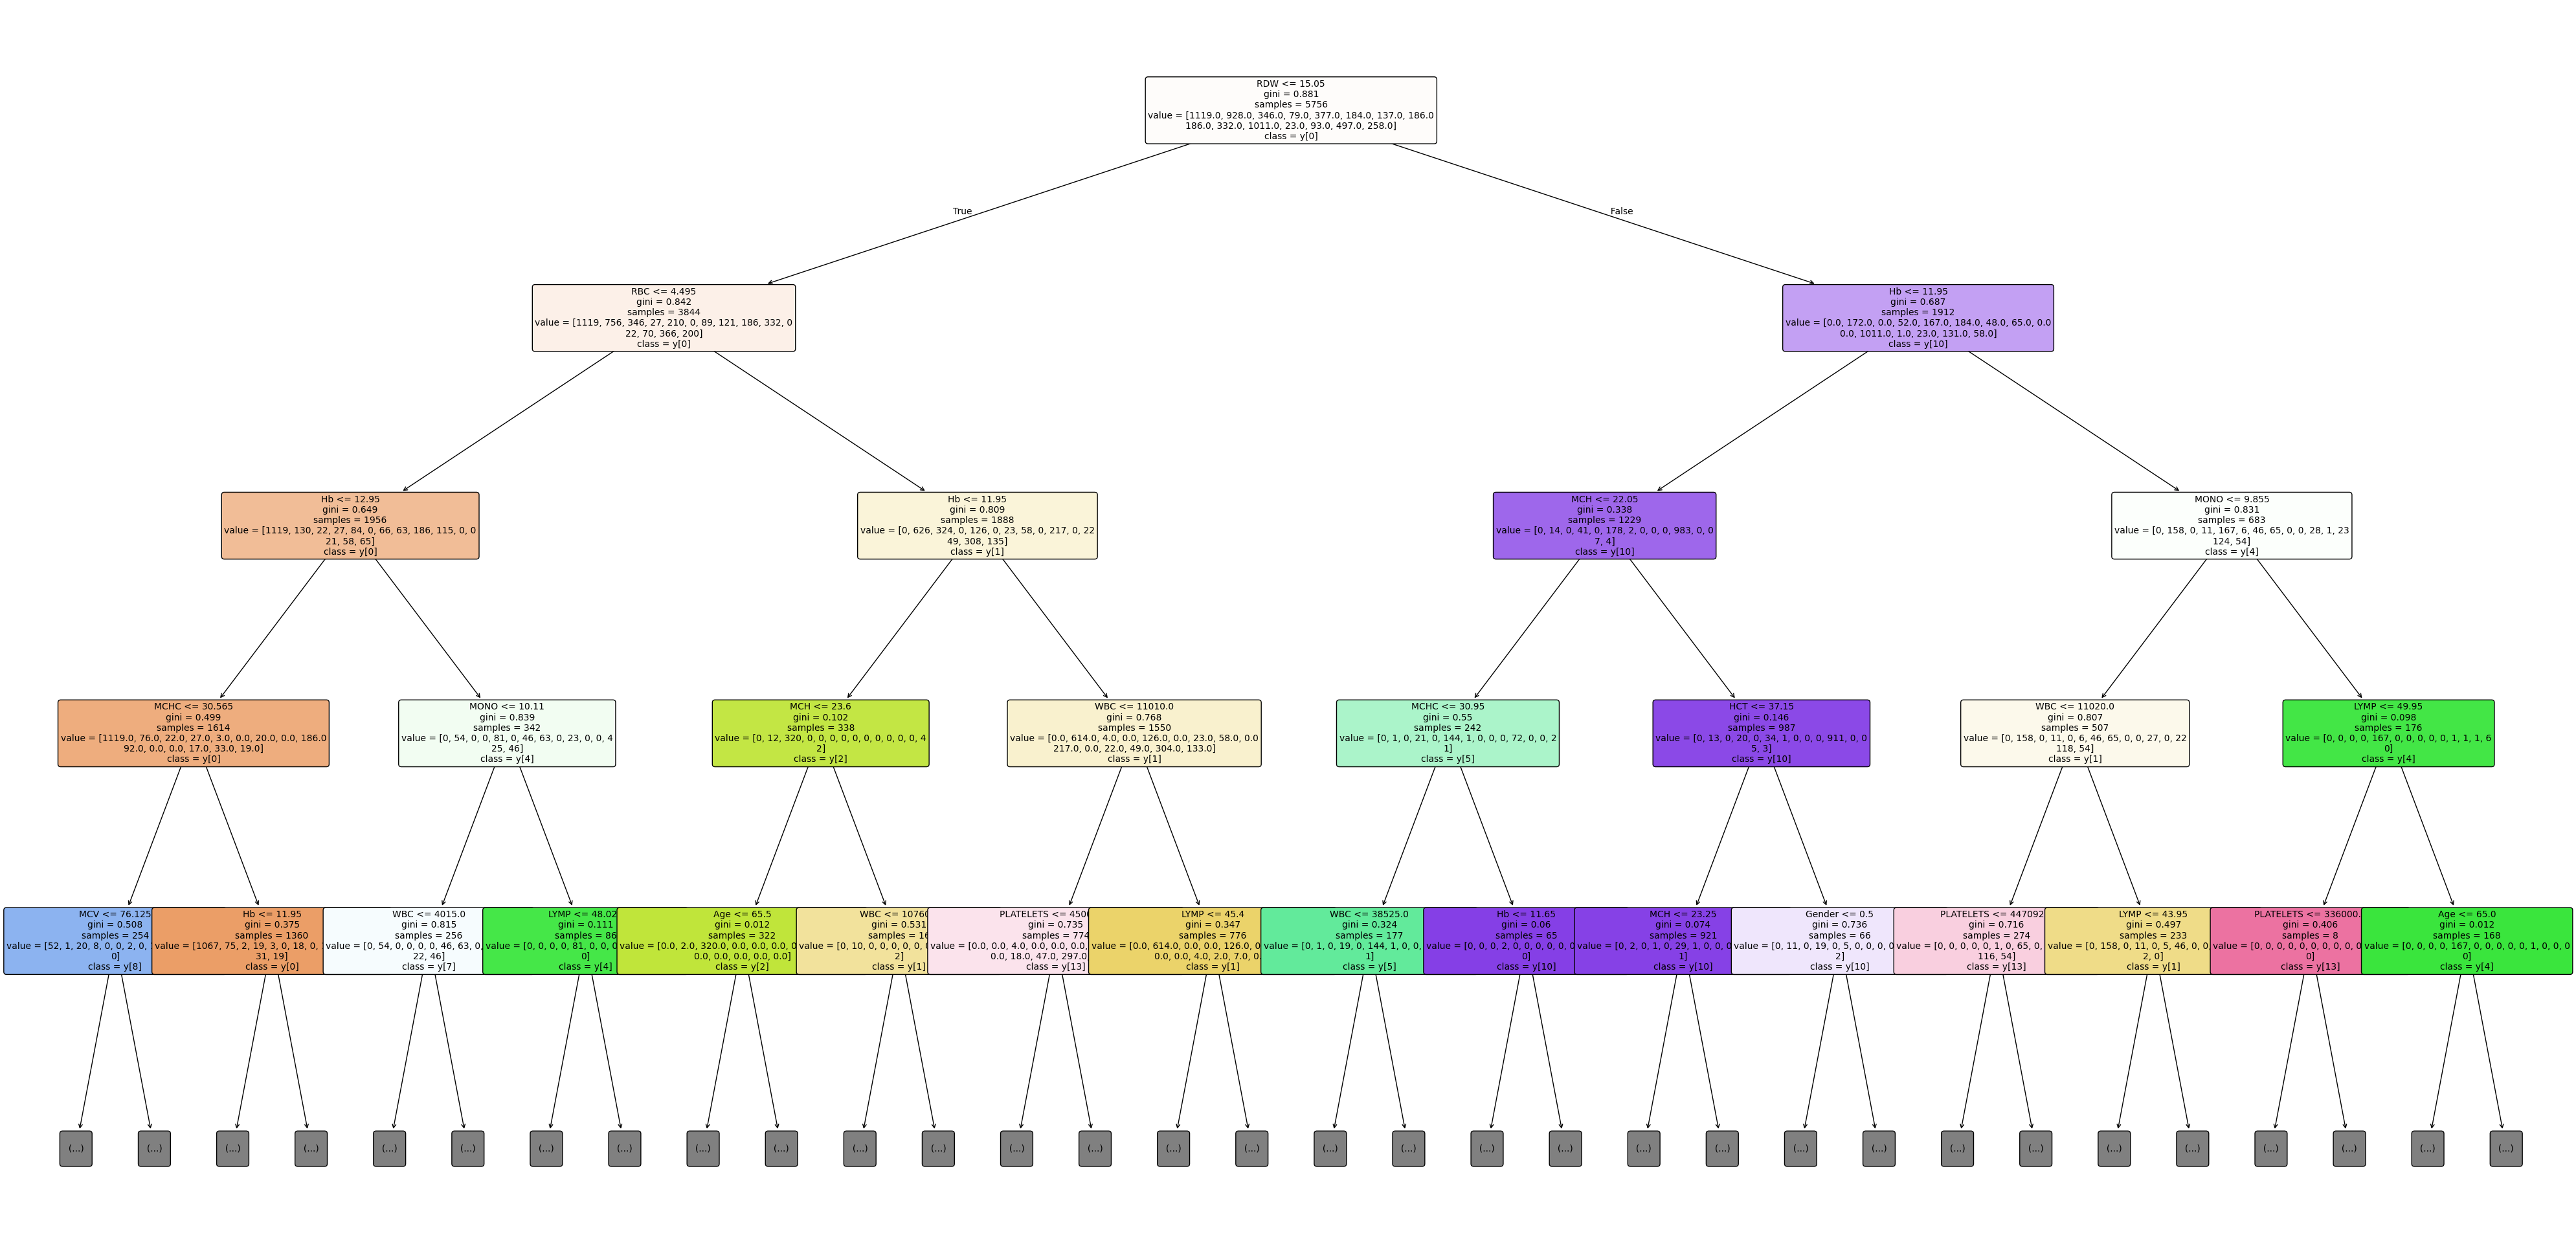

In [34]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(50,25))

plot_tree(best_model_dt, 
          max_depth=4,
          filled=True, 
          feature_names=X.columns, 
          class_names=True,
          rounded=True,
          fontsize=10
         )

plt.savefig(f"DT_best.pdf", bbox_inches='tight', dpi=300)

plt.show()

## 8. Evaluarea performaței modelului

### 8.1. Matricea de confuzie (Confusion Matrix)

Matricea de confuzie împarte predicțiile în:
- True Positive(TP): cazurile în care modelul a identificat un diagnostic corect
- True Negative(TN): cazurile în care modelul a identificat cazurile sănătoase, cu diagnostic "Normal"
- False Positive(FP): cazurile în care modelul a identificat în mod eronat un diagnotic (diagnostic greșit)
- False Negative(FN): cazurile în care modelul NU a identificat un diagnostic(diagnostic neidentificat corect).

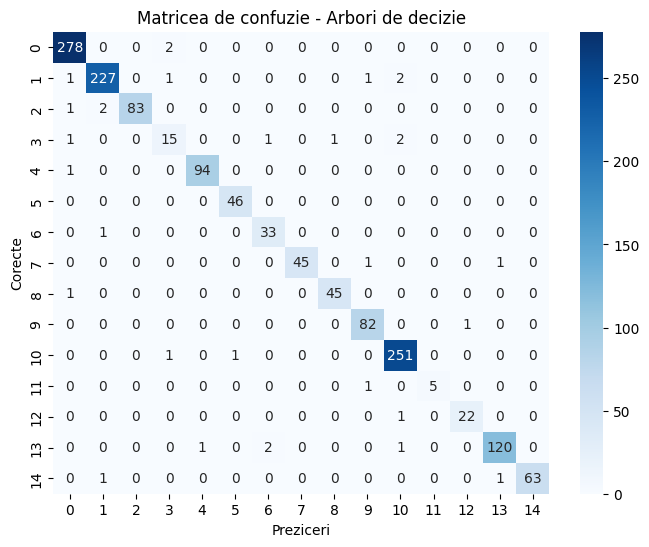

In [35]:
from sklearn.metrics import confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns

cm_dt = confusion_matrix(y_test, y_pred_dt_best)
plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Preziceri")
plt.ylabel("Corecte")
plt.title("Matricea de confuzie - Arbori de decizie")
plt.show()

### 8.2. Acuratețea

Pentru a evalua performanța modelului, vom utiliza metrica *accuracy*, care reprezintă proporția eșantioanelor clasificate corect din totalul observațiilor analizate.

Formula de calcul pentru acuratețe este: (TP+TN)/(TP+TN+FP+FN) (Numărul de predicții corecte/Numărul total de predicții)

In [36]:
accuracy_dt = accuracy_score(y_test, y_pred_dt_best)
print("Acuratețea Arborelui de Decizie: ", accuracy_dt)

Acuratețea Arborelui de Decizie:  0.9784722222222222


**Interpretare**: Modelul clasifică corect 97,84% dintre cazurile analizate.

### 8.3. Precizie, sensibilitate, specificitate, F1-score

In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np

# Generam raportul principal
report = classification_report(y_test, y_pred_dt_best, target_names=le.classes_, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Calculam Specificitatea ( TN/(TN+FP) )
cm = confusion_matrix(y_test, y_pred_dt_best)
specificity=[]

for i in range(len(le.classes_)):
    tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i,i])
    fp = np.sum(cm[:,i]) - cm[i,i]
    spec = tn / (tn + fp) if (tn+fp)>0 else 0
    specificity.append(spec)

# Adaugam specificitatea in tabel
df_report = df_report.iloc[:len(le.classes_)].copy()
df_report['specificity'] = specificity

# Afisam tabelul
print("Matrici de Performanta pe Clasa:")
print(df_report[['precision', 'recall', 'specificity', 'f1-score']].round(2))


Matrici de Performanta pe Clasa:
                           precision  recall  specificity  f1-score
Anemia of Chronic Disease       0.98    0.99         1.00      0.99
Bacterial Infections            0.98    0.98         1.00      0.98
Beta-Thalassemia Minor          1.00    0.97         1.00      0.98
Chronic Leukemias               0.79    0.75         1.00      0.77
Infectious Mononucleosis        0.99    0.99         1.00      0.99
Iron Deficiency                 0.98    1.00         1.00      0.99
Leukocytosis                    0.92    0.97         1.00      0.94
Leukopenia                      1.00    0.96         1.00      0.98
Microcytic Anemia               0.98    0.98         1.00      0.98
Normal                          0.96    0.99         1.00      0.98
Normocytic Anemia               0.98    0.99         0.99      0.98
Polycythemia Vera               1.00    0.83         1.00      0.91
Thrombocytopenia                0.96    0.96         1.00      0.96
Thrombocytosis 

Observăm Sensibilitatea(Recall) prea mică în cazul Leucemiilor Cronice(Chronic Leukemias), de doar 0.75, ceea ce înseamnă că modelul nostru reușeste să identifice corect doar 75 de cazuri din 100. Riscul este ca 25% din pacienți să fie diagnosticați fie ca sanatoși(Normal), fie cu un diagnostic greșit(Fals Negativi). Considerăm pe pentru un diagnostic oncologic, un recall de 0.75 este prea mic.

Analizând matricea ce confuzie pentru Leucemiile Cronice(Chronic Leukemias) - Cod 3, observăm că din totalul de 20 de cazuri reale, 15 au fost identificate corect(True Positives), iar 5 au fost identificate greșit(False Negatives):
- Normocytic Anemia(Cod 10): 3 cazuri
- Anemia of Chronic Disease(Cod 0): 1 caz
- Mycrocytic Anemia(Cod 8): 1 caz

Acest diagnostic greșit este foarte periculos deoarece tratarea doar a anemiei în cazul unei boli oncologice poate avea consecințe nefaste pentru pacient.

## 9. Optimizarea modelului (Hyperparameter tuning)

### 9.1. Validarea încrucișată (Cross-Validation)

Folosim Cross-validation pentru antrenarea și testarea modelului pe mai multe împărțiri ale datasetului. Alegem k=5 pentru a împărți datasetul în 5 părți egale, iar la final vom calcula media performanței.

Pentru a mări Recall-ul pentru Leucemiile Cronice(Chronic Leukemias) - Cod 3, vom reinstrui modelul că a rata o leucemie este de 5 ori mai grav decât a rata o anemie.

In [38]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier

# Definim ponderile. Clasa 3 - Chronic Leukemias primeste o pondere de 5, iar restul primesc o pondere de 1
weights = {i: 1 for i in range(15)}
weights[3] = 5 # Crestem importanta Clasei 3

# Actualizam modelul anterior cu ponderile definite
best_model_dt.set_params(class_weight=weights, random_state=42)

# Evaluam stabilitatea prin Cross-Validation 
# cv=5 inseamna ca imparte datele in 5 grupuri si testeaza de 5 ori
cv_scores = cross_val_score(best_model_dt, X_train, y_train, cv=5)

print(f"Scoruri Cross-Validation: {cv_scores}")
print(f"Media acuratetii (CV): {cv_scores.mean():.4f}")
print(f"Deviatia standard: {cv_scores.std():.4f}")


Scoruri Cross-Validation: [0.96440972 0.95655951 0.96350999 0.95395308 0.95916594]
Media acuratetii (CV): 0.9595
Deviatia standard: 0.0040


Valoarea mica a deviatiei standard ne arata ca modelul este robust, deci nu depinde de modul in care au fost amestecate datele initial.

### 9.2. Grid Search

In [39]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Extragem valorile aplha relevante
path = best_model_dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Definim grila de parametrii
param_grid = {
    'ccp_alpha': ccp_alphas[::5], # luam a 5-a valoare pentru viteza
    "max_depth":[None, 10, 15], 
    "min_samples_split":[2,5] # valori mici pentru a prinde bolile rare
}

# Configuram si rulam Grid Search
grid = GridSearchCV(best_model_dt, param_grid, cv=5, scoring='recall_macro', n_jobs=-1)
grid.fit(X_train, y_train)
print(grid.best_params_)

# Extragem modelul final
model_dt_retrained = grid.best_estimator_

# Predictia finala
y_pred_dt_retrained = model_dt_retrained.predict(X_test)

{'ccp_alpha': np.float64(0.0006420614808158322), 'max_depth': 15, 'min_samples_split': 2}


## 10. Evaluarea performanței modelului optimizat

### 10.1. Afișăm primele 4 niveluri ale arborelui

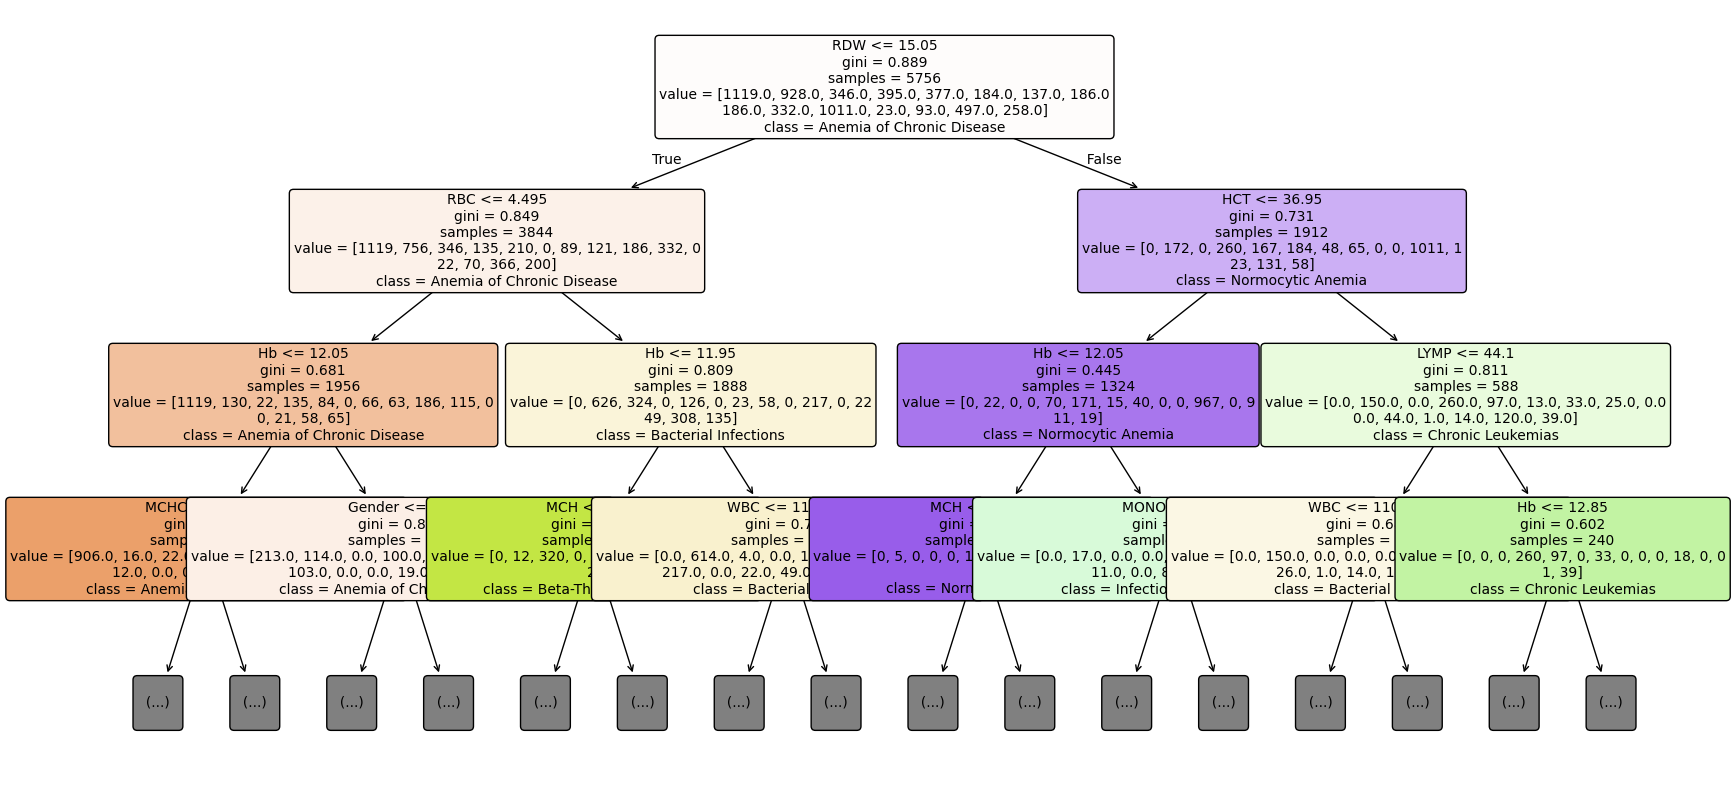

In [40]:
plt.figure(figsize=(20,10))
plot_tree(model_dt_retrained,
         feature_names=X.columns,
         class_names=le.classes_,
         filled=True,
         rounded=True,
         fontsize=10,
         max_depth=3)
plt.savefig(f"DT_retrained.pdf", bbox_inches='tight', dpi=300)
plt.show()

### 10.2. Matricea de confuzie a modelului optimizat

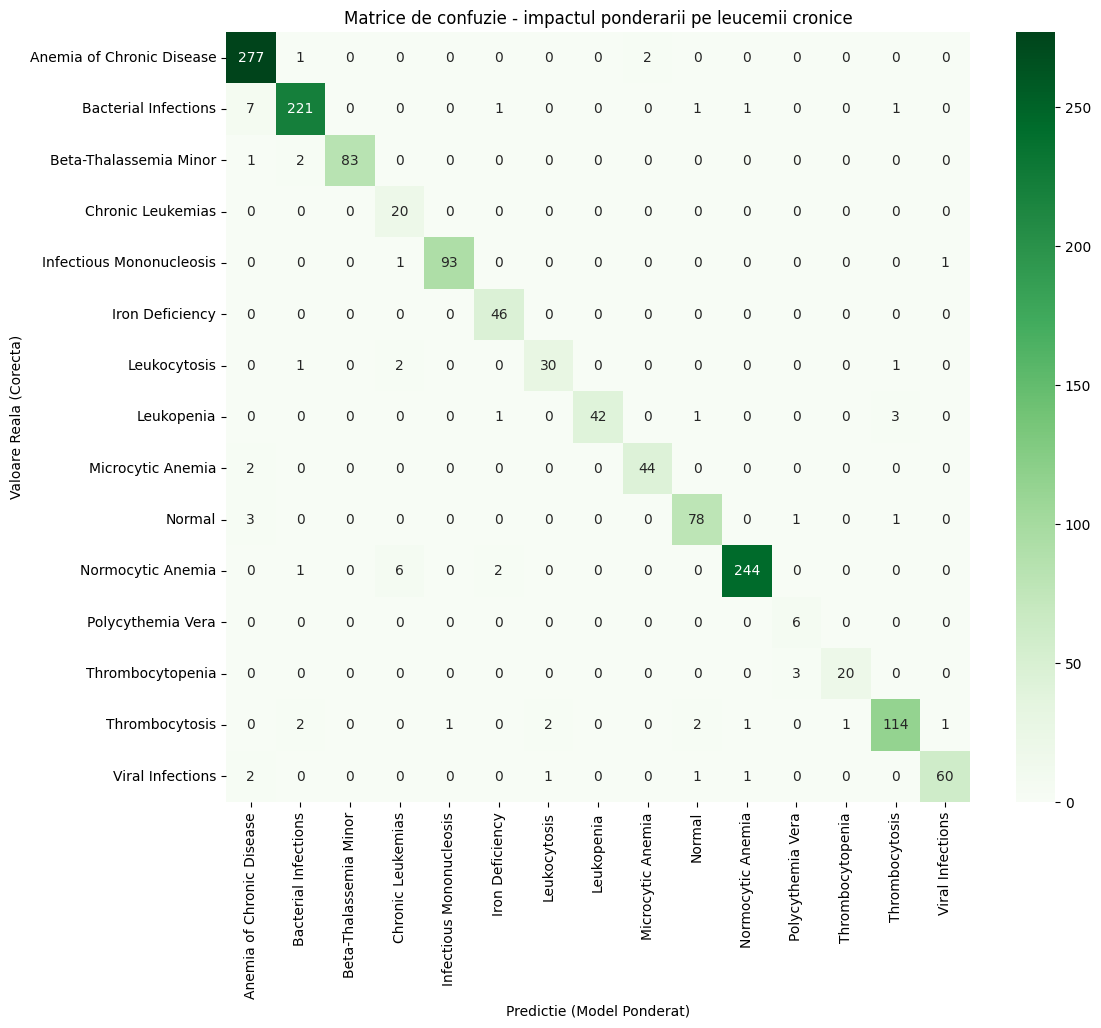

In [41]:
# Generăm noua matrice de confuzie
cm_weighted = confusion_matrix(y_test, y_pred_dt_retrained)

# Afisăm rezultatul
plt.figure(figsize=(12, 10))
sns.heatmap(cm_weighted, annot=True, fmt='d', cmap="Greens", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predictie (Model Ponderat)")
plt.ylabel("Valoare Reala (Corecta)")
plt.title("Matrice de confuzie - impactul ponderarii pe leucemii cronice")
plt.savefig(f"MC.pdf", bbox_inches='tight', dpi=300)
plt.show()

### 10.3. Acuratețea

In [42]:
accuracy_dt_retrained = accuracy_score(y_test, y_pred_dt_retrained)
print("Acuratețea Arborelui de Decizie optimizat: ", accuracy_dt_retrained)

Acuratețea Arborelui de Decizie optimizat:  0.9569444444444445


### 10.4. Raport de clasificare

In [43]:
# Afisam noul raport pentru a vedea daca recall-ul de la clasa 3 a crescut
# Generam raportul principal
report = classification_report(y_test, y_pred_dt_retrained, target_names=le.classes_, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Calculam Specificitatea ( TN/(TN+FP) )
cm = confusion_matrix(y_test, y_pred_dt_retrained)
specificity=[]

for i in range(len(le.classes_)):
    tn = np.sum(cm) - (np.sum(cm[i, :]) + np.sum(cm[:, i]) - cm[i,i])
    fp = np.sum(cm[:,i]) - cm[i,i]
    spec = tn / (tn + fp) if (tn+fp)>0 else 0
    specificity.append(spec)

# Adaugam specificitatea in tabel
df_report = df_report.iloc[:len(le.classes_)].copy()
df_report['specificity'] = specificity

# Afisam tabelul
print("Raport de clasificare cu ponderare:")
print(df_report[['precision', 'recall', 'specificity', 'f1-score']].round(2))

Raport de clasificare cu ponderare:
                           precision  recall  specificity  f1-score
Anemia of Chronic Disease       0.95    0.99         0.99      0.97
Bacterial Infections            0.97    0.95         0.99      0.96
Beta-Thalassemia Minor          1.00    0.97         1.00      0.98
Chronic Leukemias               0.69    1.00         0.99      0.82
Infectious Mononucleosis        0.99    0.98         1.00      0.98
Iron Deficiency                 0.92    1.00         1.00      0.96
Leukocytosis                    0.91    0.88         1.00      0.90
Leukopenia                      1.00    0.89         1.00      0.94
Microcytic Anemia               0.96    0.96         1.00      0.96
Normal                          0.94    0.94         1.00      0.94
Normocytic Anemia               0.99    0.96         1.00      0.98
Polycythemia Vera               0.60    1.00         1.00      0.75
Thrombocytopenia                0.95    0.87         1.00      0.91
Thrombocytos

Precizia calculează căt de corecte sunt diagnosticele pozitive:
Precision = TP / (TP + FP)

Sensibilitatea calculează cât de bine identifică diagnosticele:
Recall (Sensibilitate) = TP / (TP + FN)

Scorul F1 calculează echilibrul dintre precizie și sensibilitate:
F1 = 2 * (Precision * Recall) / (Precision + Recall)

Având în vedere faptul că analizăm un set de date medicale, acordăm o importanță mai mare sensibilității(Recall). Considerăm că este mai important să nu ratăm un diagnostic(recall mic), decât să identificăm în mod eronat un diagnostic(precizie mică).

### 10.5. Curba ROC și AUC

Verificăm distribuția în test și alegem primele 5 clase(diagnostice) în funcție de frecvența acestora. Cea de-a cincea clasă va fi înlocuită cu cea cu diagnosticul "Normal", în situația în care nu este prezentă în top 5.

In [44]:
# import numpy as np

# frecvența claselor
unique, counts = np.unique(y_test, return_counts=True)

# sortăm screscător după frecvență
sorted_indices = np.argsort(counts)

# afișăm lista claselor în ordinea frecvenței
print("Frecventa claselor in setul de test, de la cea mai rara la cea mai comuna")
for idx in sorted_indices:
    print(le.classes_[idx], ":", counts[idx])

# selectăm top 5 inițial
top_k = 5
rare_classes = unique[sorted_indices[:top_k]]

# identificăm indexul clasei "Normal"
normal_index = np.where(le.classes_ == "Normal")[0][0]

# dacă "Normal" nu este în top 5, înlocuim ultima clasă din top
if normal_index not in rare_classes:
    print("\nClasa 'Normal' nu este printre cele mai rare clase, așa că o includem manual.")
    rare_classes[-1] = normal_index

# afișare finală
print("\n\nClasele selectate automat:")
for c in rare_classes:
    print(" - ", le.classes_[c])
print("\nIndexurile claselor cele mai rare, inclusiv clasa 'Normal': ", rare_classes)

Frecventa claselor in setul de test, de la cea mai rara la cea mai comuna
Polycythemia Vera : 6
Chronic Leukemias : 20
Thrombocytopenia : 23
Leukocytosis : 34
Iron Deficiency : 46
Microcytic Anemia : 46
Leukopenia : 47
Viral Infections : 65
Normal : 83
Beta-Thalassemia Minor : 86
Infectious Mononucleosis : 95
Thrombocytosis : 124
Bacterial Infections : 232
Normocytic Anemia : 253
Anemia of Chronic Disease : 280

Clasa 'Normal' nu este printre cele mai rare clase, așa că o includem manual.


Clasele selectate automat:
 -  Polycythemia Vera
 -  Chronic Leukemias
 -  Thrombocytopenia
 -  Leukocytosis
 -  Normal

Indexurile claselor cele mai rare, inclusiv clasa 'Normal':  [11  3 12  6  9]


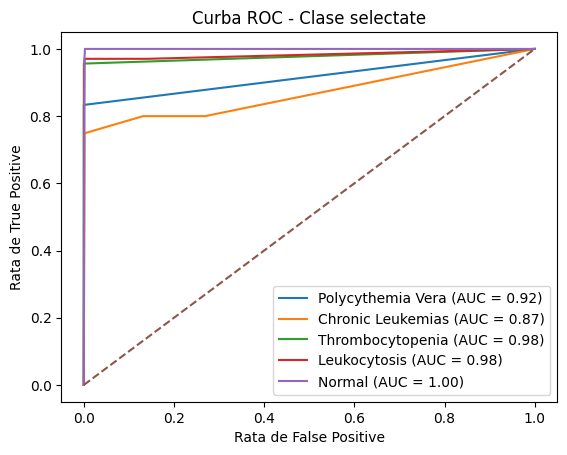

In [45]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
# import matplotlib.pyplot as plt
# import numpy as np

# Selectăm clasele dorite
# selected_classes = [11, 3, 12, 6, 9]
selected_classes = rare_classes

# Pentru afisarea tuturor claselor
# all_classes= best_model_dt.classes_

# Binarizare
y_test_bin = label_binarize(y_test, classes=selected_classes)  # pentru toate clasele inlocuim classes=all_classes

# Probabilități
y_prob_dt = best_model_dt.predict_proba(X_test)

fpr = {}
tpr = {}
roc_auc = {}

for index, class_index in enumerate(selected_classes):    # pentru toate clasele inlocuim classes=all_classes
    # verificăm dacă există exemple în clasele selectate
    if np.sum(y_test == class_index) == 0:
        print(f"Clasa {le.classes_[class_index]} nu apare in test -> skip")
        continue
    # folosim index pentru y_test_bin și class_index pentru probabilități
    fpr[class_index], tpr[class_index], _ = roc_curve(y_test_bin[:, index], y_prob_dt[:, class_index])
    roc_auc[class_index] = auc(fpr[class_index], tpr[class_index])

# Grafic pentru clasele selectate
plt.figure()
for class_index in roc_auc.keys():
    plt.plot(fpr[class_index], tpr[class_index], label=f"{le.classes_[class_index]} (AUC = {roc_auc[class_index]:.2f})")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("Rata de False Positive")
plt.ylabel("Rata de True Positive")
plt.title("Curba ROC - Clase selectate")

plt.legend()
plt.show()


In [46]:
# Macro-average
macro_auc = np.mean(list(roc_auc.values()))
print("Macro-average AUC pentru cele 5 diagnostice: ", macro_auc)

Macro-average AUC pentru cele 5 diagnostice:  0.9492099390764368


## 11. Analiza importanței atributelor medicale (Feature Importance)

Graficul de importanță

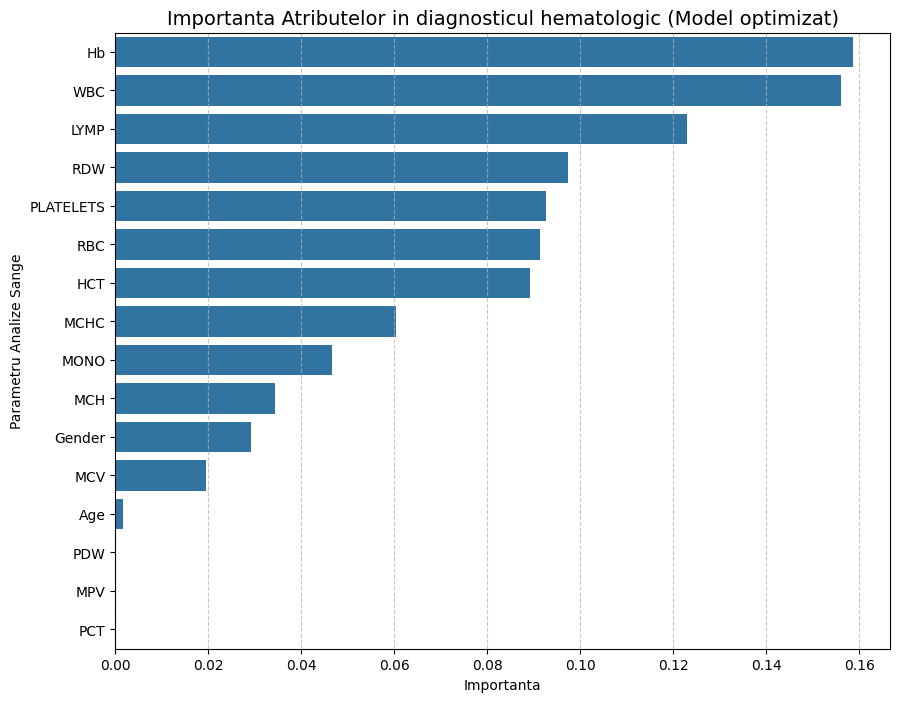

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Extragem importanta din modelul reinstruit
importances = model_dt_retrained.feature_importances_
feature_names = X.columns

# Creăm un DataFrame
feature_importance_df = pd.DataFrame({
    'Atribut Medical': feature_names,
    'Importanta': importances
}).sort_values(by='Importanta', ascending=False)

# Vizualizare
plt.figure(figsize=(10,8))
sns.barplot(x='Importanta', y='Atribut Medical', data=feature_importance_df)
plt.title('Importanta Atributelor in diagnosticul hematologic (Model optimizat)', fontsize=14)
plt.xlabel=('Scor de Importanta (Gini Importance)')
plt.ylabel('Parametru Analize Sange')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [48]:
# Afișăm și valorile numerice
print(feature_importance_df.head(16))

   Atribut Medical  Importanta
2               Hb    0.158683
4              WBC    0.155953
6             LYMP    0.123002
12             RDW    0.097417
5        PLATELETS    0.092542
3              RBC    0.091304
8              HCT    0.089295
11            MCHC    0.060289
7             MONO    0.046553
10             MCH    0.034306
0           Gender    0.029307
9              MCV    0.019573
1              Age    0.001776
13             PDW    0.000000
14             MPV    0.000000
15             PCT    0.000000


## 12. Transparența (Explainable AI)

### 12.1. Vizualizarea unui "Drum de decizie" (Decision Path)

In [49]:
# Alegem un pacient din clasa Chronic Leukemias (o clasă mai dificilă de diagnosticat)
sample_idx = np.where(y_test == 3)[0][0]
sample_data = X_test.iloc[[sample_idx]]

# Extragem drumul decizional
node_indicator = model_dt_retrained.decision_path(sample_data)
leaf_id = model_dt_retrained.apply(sample_data)
node_index = node_indicator.indices[node_indicator.indptr[0]:node_indicator.indptr[1]]

print(f"Logica de diagnostic pentru pacientul {sample_idx} (Diagnostic Real: {le.classes_[3]}):")
for node_id in node_index:
    # Verificam daca am ajuns la final(frunza)
    if leaf_id[0] == node_id:
        print(f"--> Nod frunză: Diagnosticul final este: {le.classes_[model_dt_retrained.tree_.value[node_id].argmax()]}")
        continue
    # Extragem detaliile nodului de decizie
    feature_idx = model_dt_retrained.tree_.feature[node_id]
    feature_name = X_test.columns[feature_idx]
    threshold = model_dt_retrained.tree_.threshold[node_id]
    value = sample_data.values[0, feature_idx]
    if value <= threshold:
        threshold_sign = "<="
    else:
        threshold_sign = ">"
    print(f"Nod {node_id}: Se verifica {feature_name} ({value:.2f}) {threshold_sign} Pragul {threshold:.2f}")

Logica de diagnostic pentru pacientul 157 (Diagnostic Real: Chronic Leukemias):
Nod 0: Se verifica RDW (15.40) > Pragul 15.05
Nod 120: Se verifica HCT (39.00) > Pragul 36.95
Nod 154: Se verifica LYMP (53.00) > Pragul 44.10
Nod 172: Se verifica Hb (11.50) <= Pragul 12.85
Nod 173: Se verifica WBC (92310.00) > Pragul 18760.00
Nod 179: Se verifica PLATELETS (501000.00) <= Pragul 768070.00
--> Nod frunză: Diagnosticul final este: Chronic Leukemias


### 12.2. Reguli IF-THEN

Extragem regulile:

In [50]:
from sklearn.tree import _tree
def extract_rules(model_dt_retrained, feature_names, class_names):
    tree =  model_dt_retrained.tree_
    rules=[]

    def recurse(node, rule):
        if tree.feature[node] != -2: # nu este o frunza
            name = feature_names[tree.feature[node]]
            threshold = tree.threshold[node]

            recurse(tree.children_left[node], rule + [f"{name} <= {threshold:.2f}"])
            recurse(tree.children_right[node], rule + [f"{name} > {threshold:.2f}"])
        else: # este o frunza
            value = tree.value[node][0]
            class_id = value.argmax()
            samples = int(tree.n_node_samples[node])

            rules.append({
                "rule": " AND ".join(rule),
                "class": class_names[class_id],
                "samples": samples})
    recurse(0,[])
    return rules

#extragem regulile
rules = extract_rules(model_dt_retrained, X.columns, le.classes_)

Creăm un dicționar medical pentru atribute:

In [51]:
medical_dict = {
    "Age": "vârsta",
    "Gender":"genul",
    "Hb": "nivelul hemoglobinei",
    "RBC":"numărul de eritrocite - Red Blood Cells",
    "WBC":"numărul de leucocite - White Blood Cells",
    "PLATELETS":"numărul de trombocite",
    "LYMP": "proportia limfocitelor",
    "MONO": "proporția monocitelor",
    "HCT": "hematocritul",
    "MCV":"Volumul Erotricitar Mediu",
    "MCH":"Hemoglobină Eritrocitară Medie",
    "MCHC":"Concentrație Medie de Hemoglobină Eritrocitară",
    "RDW":"variabilitatea dimensiunii eritrocitelor",
    "PDW":"variabilitatea dimensiunii trombocitelor",
    "MPV":"Volum Mediu Trombocitar",
    "PCT":"Procalcitonina"
}

Creăm o funcție de traducere care utilizează dicționarul medical:

In [52]:
def interpret_rules(rule):
    parts = rule.split(" AND ")
    interpreted=[]

    for p in parts:
        for feature in medical_dict:
            if feature in p:
                text = p.replace(feature, medical_dict[feature])
                interpreted.append(text)
    return " și ".join(interpreted)

Construim un tabel de interpretare clinică a regulilor:

In [53]:
# import pandas as pd

# Configuram pandas sa nu truncheze textul
pd.set_option('display.max_colwidth', None) # Afiseaza tot textul din celule
pd.set_option('display.max_rows', None) # Afiseaza toate randurile

table_rules =[]

for r in rules:
    table_rules.append({
        "Diagnostic": r["class"],
        "Regula ML": r["rule"],
        "Număr pacienți": r["samples"],
        "Interpretarea clinică": interpret_rules(r["rule"])
    })

# Cream DataFrame-ul
df_rules=pd.DataFrame(table_rules)

# Grupam regulile in functie de diagnostic si dupa numarul de pacienti
df_rules = df_rules.sort_values(by=['Diagnostic', 'Număr pacienți'], ascending=[True, False])
df_rules = df_rules.reset_index(drop=True) # resetam indexul

# Afisam tabelul
display(df_rules)

# Exportam in excel
df_rules.to_csv("Reguli_Diagnostic.csv")

,Diagnostic,Regula ML,Număr pacienți,Interpretarea clinică
0,Anemia of Chronic Disease,RDW <= 15.05 AND RBC <= 4.49 AND Hb <= 12.05 AND MCHC > 30.57 AND HCT <= 36.85 AND PLATELETS <= 778280.50 AND MCV > 71.65 AND Age <= 66.50,807,variabilitatea dimensiunii eritrocitelor <= 15.05 și numărul de eritrocite - Red Blood Cells <= 4.49 și nivelul hemoglobinei <= 12.05 și Hemoglobină Eritrocitară MedieC > 30.57 și Concentrație Medie de Hemoglobină Eritrocitară > 30.57 și hematocritul <= 36.85 și numărul de trombocite <= 778280.50 și Volumul Erotricitar Mediu > 71.65 și vârsta <= 66.50
1,Anemia of Chronic Disease,RDW <= 15.05 AND RBC <= 4.49 AND Hb > 12.05 AND Gender <= 0.50 AND HCT <= 39.99 AND MCHC > 30.75 AND Hb <= 12.95 AND PLATELETS <= 616466.50,204,variabilitatea dimensiunii eritrocitelor <= 15.05 și numărul de eritrocite - Red Blood Cells <= 4.49 și nivelul hemoglobinei > 12.05 și genul <= 0.50 și hematocritul <= 39.99 și Hemoglobină Eritrocitară MedieC > 30.75 și Concentrație Medie de Hemoglobină Eritrocitară > 30.75 și nivelul hemoglobinei <= 12.95 și numărul de trombocite <= 616466.50
2,Anemia of Chronic Disease,RDW <= 15.05 AND RBC <= 4.49 AND Hb <= 12.05 AND MCHC > 30.57 AND HCT > 36.85 AND Gender <= 0.50 AND MCV > 74.90,42,variabilitatea dimensiunii eritrocitelor <= 15.05 și numărul de eritrocite - Red Blood Cells <= 4.49 și nivelul hemoglobinei <= 12.05 și Hemoglobină Eritrocitară MedieC > 30.57 și Concentrație Medie de Hemoglobină Eritrocitară > 30.57 și hematocritul > 36.85 și genul <= 0.50 și Volumul Erotricitar Mediu > 74.90
3,Anemia of Chronic Disease,RDW <= 15.05 AND RBC <= 4.49 AND Hb <= 12.05 AND MCHC <= 30.57 AND MCV > 76.12,37,variabilitatea dimensiunii eritrocitelor <= 15.05 și numărul de eritrocite - Red Blood Cells <= 4.49 și nivelul hemoglobinei <= 12.05 și Hemoglobină Eritrocitară MedieC <= 30.57 și Concentrație Medie de Hemoglobină Eritrocitară <= 30.57 și Volumul Erotricitar Mediu > 76.12
4,Anemia of Chronic Disease,RDW <= 15.05 AND RBC <= 4.49 AND Hb <= 12.05 AND MCHC > 30.57 AND HCT <= 36.85 AND PLATELETS <= 778280.50 AND MCV > 71.65 AND Age > 66.50 AND WBC <= 11720.00,14,variabilitatea dimensiunii eritrocitelor <= 15.05 și numărul de eritrocite - Red Blood Cells <= 4.49 și nivelul hemoglobinei <= 12.05 și Hemoglobină Eritrocitară MedieC > 30.57 și Concentrație Medie de Hemoglobină Eritrocitară > 30.57 și hematocritul <= 36.85 și numărul de trombocite <= 778280.50 și Volumul Erotricitar Mediu > 71.65 și vârsta > 66.50 și numărul de leucocite - White Blood Cells <= 11720.00
5,Anemia of Chronic Disease,RDW <= 15.05 AND RBC <= 4.49 AND Hb <= 12.05 AND MCHC > 30.57 AND HCT <= 36.85 AND PLATELETS <= 778280.50 AND MCV <= 71.65 AND RDW > 13.98,13,variabilitatea dimensiunii eritrocitelor <= 15.05 și numărul de eritrocite - Red Blood Cells <= 4.49 și nivelul hemoglobinei <= 12.05 și Hemoglobină Eritrocitară MedieC > 30.57 și Concentrație Medie de Hemoglobină Eritrocitară > 30.57 și hematocritul <= 36.85 și numărul de trombocite <= 778280.50 și Volumul Erotricitar Mediu <= 71.65 și variabilitatea dimensiunii eritrocitelor > 13.98
6,Anemia of Chronic Disease,RDW <= 15.05 AND RBC <= 4.49 AND Hb > 12.05 AND Gender <= 0.50 AND HCT <= 39.99 AND MCHC <= 30.75 AND MCV > 76.40,12,variabilitatea dimensiunii eritrocitelor <= 15.05 și numărul de eritrocite - Red Blood Cells <= 4.49 și nivelul hemoglobinei > 12.05 și genul <= 0.50 și hematocritul <= 39.99 și Hemoglobină Eritrocitară MedieC <= 30.75 și Concentrație Medie de Hemoglobină Eritrocitară <= 30.75 și Volumul Erotricitar Mediu > 76.40
7,Anemia of Chronic Disease,RDW <= 15.05 AND RBC <= 4.49 AND Hb <= 12.05 AND MCHC <= 30.57 AND MCV <= 76.12 AND RBC <= 3.81 AND MCH > 27.10,7,variabilitatea dimensiunii eritrocitelor <= 15.05 și numărul de eritrocite - Red Blood Cells <= 4.49 și nivelul hemoglobinei <= 12.05 și Hemoglobină Eritrocitară MedieC <= 30.57 și Concentrație Medie de Hemoglobină Eritrocitară <= 30.57 și Volumul Erotricitar Mediu <= 76.12 și numărul de eritrocit

Extragem regulile pentru leucemiile cronice:

In [54]:
leukemia_rules = [r for r in rules if r["class"] == "Chronic Leukemias"]

for i, r in enumerate(leukemia_rules, 1):
    print(f"LEUKEMIA RULE {i} (samples={r['samples']}): IF {r['rule']}")

LEUKEMIA RULE 1 (samples=8): IF RDW <= 15.05 AND RBC <= 4.49 AND Hb <= 12.05 AND MCHC > 30.57 AND HCT > 36.85 AND Gender > 0.50 AND RBC <= 3.65
LEUKEMIA RULE 2 (samples=22): IF RDW <= 15.05 AND RBC <= 4.49 AND Hb > 12.05 AND Gender <= 0.50 AND HCT > 39.99 AND Hb <= 12.95
LEUKEMIA RULE 3 (samples=68): IF RDW > 15.05 AND HCT > 36.95 AND LYMP > 44.10 AND Hb <= 12.85 AND WBC > 18760.00 AND PLATELETS <= 768070.00


Flux decizional

In [55]:
# Extragem drumul decizional
node_indicator_dt = model_dt_retrained.decision_path(df_pacient_2)
leaf_id_dt = model_dt_retrained.apply(df_pacient_2)[0] # ID-ul nodului final
node_index_dt = node_indicator_dt.indices[node_indicator_dt.indptr[0]:node_indicator_dt.indptr[1]]

print(f"Logica de diagnostic pentru pacientul nou:")
for node_id in node_index_dt:
    # Verificam daca am ajuns la final(frunza)
    if leaf_id_dt == node_id:
        # Extragem clasa cu probabilitatea maxima din acel nod
        class_idx = model_dt_retrained.tree_.value[node_id].argmax()
        final_diagnostic = le.classes_[class_idx]
        print(f"--> Nod frunză {node_id}: Diagnosticul final este: {final_diagnostic}")
        continue
    # Extragem detaliile nodului de decizie
    feature_idx = model_dt_retrained.tree_.feature[node_id]
    feature_name = df_pacient_2.columns[feature_idx]
    threshold = model_dt_retrained.tree_.threshold[node_id]
    value = df_pacient_2.iloc[0, feature_idx]
    if value <= threshold:
        threshold_sign = "<="
    else:
        threshold_sign = ">"
    print(f"Nod {node_id}: Se verifica {feature_name} ({value:.2f}) {threshold_sign} Pragul {threshold:.2f}")

NameError: name 'df_pacient_2' is not defined

## 13. Compararea cu alte modele

### 13.1. Random Forest

#### 13.1.1. Implementarea modelului Random Forest

Random Forest construiește mai mulți arbori de decizie, unde fiecare arbore face o predicție, iar rezultatul final este reprezentat de rezultatul majoritar al arborilor.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100, class_weight=weights, random_state=42)
model_rf.fit(X_train, y_train)

#### 13.1.2 Generarea predicțiilor

In [ ]:
y_pred_rf = model_rf.predict(X_test)

#### 13.1.3. Matricea de confuzie (Confusion Matrix)

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import importlib

# Reîncărcăm biblioteca
importlib.reload(plt)

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Matricea de confuzie - Random Forest")
plt.show()

***Notă:*** Diagonala principală conține predicțiile clasificate corect, iar elementele din afara diagonalei sunt erorile de clasificare. 

#### 13.1.4. Calcularea acurateței (accuracy)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Acuratețe Random Forest: ", accuracy_rf)

Observăm că acuratețea modelului Random Forest este de 97,84%, mai mare decât acuratețea modelului Decision Tree de 95,69%.

#### 13.1.5. Raport de clasificare

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

#### 13.1.6. Importanța parametrilor

In [ ]:
import pandas as pd
importance = model_rf.feature_importances_
feature_importance = pd.DataFrame({"Parametru":X.columns, "Importanta":importance})
feature_importance = feature_importance.sort_values(by="Importanta", ascending=False)
print(feature_importance)

plt.figure(figsize=(8,5))
sns.barplot(x=importance, y=X.columns)
plt.title("Importanța parametrilor")
plt.show()

#### 13.1.7. Cross-Validation

Pentru a evalua stabilitatea modelului, vom folosi mai jos metoda k-fold cross-validation cu k=5. Această metodă presupune împărțirea datasetului în 5 subseturi și antrenarea modelului de 5 ori.

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model_rf, X, y_encoded, cv=5)
print("Scorurile Cross Validation: ", scores)
print("Media scorurilor: ", scores.mean())

#### 13.1.8. Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators":[100, 200], 
    "max_depth": [None, 10], 
    "class_weight": [
        {i: 1 for i in range(15)},
        {i: 1 for i in range(15) if i != 3} | {3: 5}
    ]
    }
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid, 
    cv=5, 
    n_jobs=-1,
    scoring='recall_macro' # cel mai bun mod de a forta modelul sa gaseasca cazurile pozitive(bolnavii)
)
grid_search.fit(X_train, y_train)

In [ ]:
print("Cei mai buni parametrii: ")
print(grid_search.best_params_)

In [ ]:
print("Scorul optim: ", grid_search.best_score_)

#### 13.1.9. Construirea modelului optim

In [ ]:
best_model_rf = grid_search.best_estimator_
y_pred_rf_best = best_model_rf.predict(X_test)

#### 13.1.10. Importanța parametrilor după optimizare

In [ ]:
import pandas as pd
importance = best_model_rf.feature_importances_
feature_importance = pd.DataFrame({"Parametru":X.columns, "Importanta":importance})
feature_importance = feature_importance.sort_values(by="Importanta", ascending=False)
print(feature_importance)

plt.figure(figsize=(8,5))
sns.barplot(x=importance, y=X.columns)
plt.title("Importanța parametrilor după optimizare")
plt.show()

#### 13.1.11. Raportul de clasificare

In [ ]:
print(classification_report(y_test, y_pred_rf_best))

### 13.2. Logistic Regression și SVM

Pregătirea și antrenarea modelelor

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report

custom_weights= {i: 1 for i in range(15)}
custom_weights[3]=10 # Prioritate Chronic Leukemias

# Pipeline pentru Logistic Regression(Model Liniar)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight=custom_weights, max_iter=1000, random_state=42))
])

# Pipeline pentru SVM(Model geometric)
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight=custom_weights, kernel='rbf', probability=True, random_state=42))
])

# Antrenare
lr_pipeline.fit(X_train, y_train)
svm_pipeline.fit(X_train, y_train)

# Predicții
y_pred_lr = lr_pipeline.predict(X_test)
y_pred_svm = svm_pipeline.predict(X_test)

### 13.3. Comparație privind performanța

In [ ]:
# Colectarea metricilor
models_performance = []

all_models = [
    ("Decision Tree", y_pred_dt_retrained),
    ("Random Forest", y_pred_rf_best),
    ("Logistic Regression", y_pred_lr),
    ("SVM", y_pred_svm)
]

for name, y_pred in all_models:
    report = classification_report(y_test, y_pred, output_dict=True)
    models_performance.append({
        "Model": name,
        "Acuratețea Generală": accuracy_score(y_test, y_pred),
        "Recall (Macro Average)": report['macro avg']['recall'],
        "F1-Score (Macro Average)": report['macro avg']['f1-score'],
        "Recall Leucemii (Clasa 3)": report['3']['recall'] if report else report['3.0']['recall']
    })

# Creăm tabelul comparativ
df_comparison = pd.DataFrame(models_performance)
display(df_comparison.round(3))

Vizualizare comparativă a Curbei ROC

In [ ]:
from sklearn.preprocessing import label_binarize

# Binarizăm etichetele pentru multiclasă
y_test_bin = label_binarize(y_test, classes=range(15))

plt.figure(figsize=(10,7))

#Definim modelele si culorile lor
models_to_plot = [
    ("Decision Tree", model_dt_retrained, "green"),
    ("Random Forest", best_model_rf, "blue"),
    ("Logistic Regression", lr_pipeline, "orange"),
    ("SVM", svm_pipeline, "purple")
]

for name, model, color in models_to_plot:
    # Obtinem probabilitatile de predictie
    y_score = model.predict_proba(X_test)
    # Calculam ROC si AUC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', color=color, lw=2)

# Adaugam linia de referinta (Random Guess)
plt.plot([0,1], [0,1], "k--", lw=1, alpha=0.5)
plt.xlabel('Rata False Positive (Specificitate)')
plt.ylabel('Rata True Positive (Sensibilitate)')
plt.title('Comparatia ROC')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.show()

Comparația matricelor de confuzie

In [ ]:
# Configurăm spațiul pentru 4 grafice
fig, axes = plt.subplots(2, 2, figsize=(22,18))
axes = axes.flatten()

models_preds = [
    ("Decision Tree", y_pred_dt_retrained, "Greens"),
    ("Random Forest", y_pred_rf_best, "Blues"),
    ("Logistic Regression", y_pred_lr, "Oranges"),
    ("SVM", y_pred_svm, "Purples")
]

for i, (name, y_pred, color) in enumerate(models_preds):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=color,
               xticklabels=le.classes_, yticklabels=le.classes_,
               ax=axes[i], cbar=False)
    axes[i].set_title(f"Matricea de Confuzie: {name}", fontsize=16, fontweight='bold')
    axes[i].set_xlabel("Predicție Model", fontsize=12)
    axes[i].set_ylabel("Diagnostic Real", fontsize=12)
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 14. Predicția diagnosticului pentru un nou set de date folosind modelul Decision Tree

In [ ]:
# Definim noile analize
# Ordinea analizelor trebuie sa fie: Gender, Age, Hb, RBC, WBC, PLATELETS, LYMP, MONO, HCT, MCV, MCH, MCHC, RDW, PDW, MPV, PCT, toate de tip float64 cu exceptia Gender, Age si WBC care sunt de tip int64
analize_pacient_nou = [[0,       # Gender (0=F)
                        35,      # Age
                        9.5,     # Hb
                        3.8,     # RBC
                        7200,    # WBC
                        410000,  # PLATELETS
                        25,      # LYMP
                        5.0,     # MONO
                        30.1,    # HCT
                        75.2,    # MCV
                        24.5,    # MCH
                        31.2,    # MCHC
                        17.5,    # RDW
                        14.0,    # PDW
                        9.5,     # MPV
                        0.35     # PCT
                       ]]

# Transormam in DataFrame
coloane = X.columns
df_pacient = pd.DataFrame(analize_pacient_nou, columns=coloane)

# predictia codificata
cod_diagnostic = model_dt_retrained.predict(df_pacient)[0]

# decodificare in text
nume_diagnostic = le.inverse_transform([cod_diagnostic])[0]

print(f"Diagnosticul sugerat de \n modelul DT: {nume_diagnostic}")

probabilitati = model_dt_retrained.predict_proba(df_pacient)
for diagnostic, prob in zip(le.classes_, probabilitati[0]):
    if prob > 0:
        print(f"{diagnostic}: {prob*100:.2f}%")

### Testare pacient care are atat Anemie Feripriva(Iron Deficiency), cat si Infectie Bacteriala (Bacterial Infection)

In [ ]:
# Definim noile analize
# Ordinea analizelor trebuie sa fie: Gender, Age, Hb, RBC, WBC, PLATELETS, LYMP, MONO, HCT, MCV, MCH, MCHC, RDW, PDW, MPV, PCT, toate de tip float64 cu exceptia Gender, Age si WBC care sunt de tip int64
analize_pacient_nou_2 = [[0,       # Gender (0=F)
                        35,      # Age
                        11.8,     # Hb scazuta sub 12 regula 28/29 ID
                        4.1,     # RBC (crescut la BI, dar scazut la ID)
                        11500,    # WBC crescut - regula 9 BI
                        350000,  # PLATELETS scazute BI regula 11                      
                        40,      # LYMP scazuta sub pragul de 44.10 regula BI
                        8.5,     # MONO usub pragul de la regula 9
                        37.5,    # HCT Scazut (Anemie) sub pragul de la regula 28, peste pragul de la regula 11
                        72.0,    # MCV sub pragul de la regula 28 IDl <80 ID
                        20.5,    # MCH scazut (Hipocromie) <27 ID - sub pragul de la regula 28
                        29.0,    # MCHC scazut (Hipocromie)  scazut ID - sub pragul de la regula 28
                        18.5,    # RDW crescut BI - peste pragul pentru ambele reguli
                        14.0,    # PDW 
                        12.5,     # MPV valoare crescuta corelata cu PCT 
                        0.45     # PCT   crescut BI
                       ]]
# Transformam in DataFrame
coloane_2 = X.columns
df_pacient_2 = pd.DataFrame(analize_pacient_nou_2, columns=coloane_2)


### Rezultate Decision Tree

In [ ]:
# predictia codificata
cod_diagnostic_2 = model_dt_retrained.predict(df_pacient_2)[0]

# decodificare in text
nume_diagnostic_2 = le.inverse_transform([cod_diagnostic_2])[0]

print(f"Diagnosticul sugerat de modelul DT: {nume_diagnostic_2}")

# Obtinem probabilitatile de la model
probabilitati_dt = model_dt_retrained.predict_proba(df_pacient_2)[0]

# Cream o lista de perechi (Diagnostic, Probabilitate)
lista_diagnostice_dt = list(zip(le.classes_, probabilitati_dt))

# Sortam lista descrescator
lista_sortata_dt = sorted(lista_diagnostice_dt, key=lambda x: x[1], reverse=True)

# Afisam lista ordonata
print("Raport probabilitati:")
for diagnostic_dt, prob_dt in lista_sortata_dt:
    if prob_dt > 0:
        print(f"{diagnostic_dt}: {prob_dt*100:.2f}%")

#### Vizualizare drum de decizie

In [ ]:
# Extragem drumul decizional
node_indicator_dt = model_dt_retrained.decision_path(df_pacient_2)
leaf_id_dt = model_dt_retrained.apply(df_pacient_2)[0] # ID-ul nodului final
node_index_dt = node_indicator_dt.indices[node_indicator_dt.indptr[0]:node_indicator_dt.indptr[1]]

print(f"Logica de diagnostic pentru pacientul nou:")
for node_id in node_index_dt:
    # Verificam daca am ajuns la final(frunza)
    if leaf_id_dt == node_id:
        # Extragem clasa cu probabilitatea maxima din acel nod
        class_idx = model_dt_retrained.tree_.value[node_id].argmax()
        final_diagnostic = le.classes_[class_idx]
        print(f"--> Nod frunză {node_id}: Diagnosticul final este: {final_diagnostic}")
        continue
    # Extragem detaliile nodului de decizie
    feature_idx = model_dt_retrained.tree_.feature[node_id]
    feature_name = df_pacient_2.columns[feature_idx]
    threshold = model_dt_retrained.tree_.threshold[node_id]
    value = df_pacient_2.iloc[0, feature_idx]
    if value <= threshold:
        threshold_sign = "<="
    else:
        threshold_sign = ">"
    print(f"Nod {node_id}: Se verifica {feature_name} ({value:.2f}) {threshold_sign} Pragul {threshold:.2f}")

### Rezultate Random Forest

In [ ]:
# predictia codificata
cod_diagnostic_3 = best_model_rf.predict(df_pacient_2)[0]

# decodificare in text
nume_diagnostic_3 = le.inverse_transform([cod_diagnostic_3])[0]

print(f"Diagnosticul sugerat de modelul RF: {nume_diagnostic_3}")

# Obtinem probabilitatile de la model
probabilitati_rf = best_model_rf.predict_proba(df_pacient_2)[0]

# Cream o lista de perechi (Diagnostic, Probabilitate)
lista_diagnostice_rf = list(zip(le.classes_, probabilitati_rf))

# Sortam lista descrescator
lista_sortata_rf = sorted(lista_diagnostice_rf, key=lambda x: x[1], reverse=True)

# Afisam lista ordonata
print("Raport probabilitati:")
for diagnostic_rf, prob_rf in lista_sortata_rf:
    if prob_rf > 0:
        print(f"{diagnostic_rf}: {prob_rf*100:.2f}%")